# JJAS prediction using previous-year OND features

This notebook builds JJAS prediction samples using past JJAS lookbacks and the previous year's OND total
for the same station (lat/lon). It then trains KNN, ELM and an ANN (LM-trained) and produces time-series
and spatial visualizations similar to `OND_with_JJAS.ipynb`. 

In [2]:
# Standard imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from shapely.geometry import box
import geopandas as gpd
import torch
import torch.nn as nn
from dataclasses import dataclass
from torch.nn.utils import parameters_to_vector, vector_to_parameters

# Dataset preparation: JJAS with previous-year OND feature
class JJASDatasetPreparation:
    """Prepare JJAS samples using previous-year OND as an extra feature."""
    def __init__(self):
        self.scaler = MinMaxScaler()
    def prepare_train_test_data(self, jjas_df: pd.DataFrame, ond_df: pd.DataFrame, jjas_col='JJAS_SUM', ond_col='OND_SUM', lookback=3, split_year=2010):
        # Shift OND forward one year so OND_{t-1} aligns with JJAS_t
        ond_prev = ond_df.copy()
        ond_prev['YEAR'] = ond_prev['YEAR'] + 1
        ond_prev = ond_prev[['YEAR', 'LATITUDE', 'LONGITUDE', ond_col]]
        merged = pd.merge(jjas_df, ond_prev, on=['YEAR', 'LATITUDE', 'LONGITUDE'], how='left')
        X, y, y_meta = [], [], []
        merged[f'{jjas_col}_norm'] = self.scaler.fit_transform(merged[[jjas_col]])
        merged[f'{ond_col}_prev_norm'] = MinMaxScaler().fit_transform(merged[[ond_col]])
        grouped = merged.groupby(['LATITUDE', 'LONGITUDE'])
        for _, group in grouped:
            series = group[f'{jjas_col}_norm'].values
            years = group['YEAR'].values
            lats = group['LATITUDE'].values
            lons = group['LONGITUDE'].values
            ond_prev_series = group[f'{ond_col}_prev_norm'].values
            if len(series) <= lookback:
                continue
            for i in range(len(series) - lookback):
                jj_look = series[i:i+lookback]
                ond_prev_val = ond_prev_series[i+lookback]
                feat = np.concatenate([jj_look, [ond_prev_val]])
                X.append(feat)
                y.append(series[i+lookback])
                y_meta.append({'YEAR': int(years[i+lookback]), 'LATITUDE': float(lats[i+lookback]), 'LONGITUDE': float(lons[i+lookback])})
        X = np.array(X)
        y = np.array(y)
        y_meta_df = pd.DataFrame(y_meta)
        train_idx = y_meta_df['YEAR'] <= split_year
        test_idx = y_meta_df['YEAR'] > split_year
        x_train, x_test = X[train_idx.values], X[test_idx.values]
        y_train, y_test = y[train_idx.values], y[test_idx.values]
        y_test_meta = y_meta_df[test_idx.values].reset_index(drop=True)
        return x_train, x_test, y_train, y_test, y_test_meta
    def normalizer_inverse_transform_array(self, data):
        vals = np.array(data).reshape(-1, 1)
        return self.scaler.inverse_transform(vals).flatten()

# Load data and prepare
jjas = pd.read_csv('data/kerala_jjas.csv')
ond = pd.read_csv('data/kerala_ond.csv')
prep = JJASDatasetPreparation()
x_train, x_test, y_train, y_test, y_test_meta = prep.prepare_train_test_data(jjas, ond, lookback=3, split_year=2010)
print('x_train', x_train.shape, 'x_test', x_test.shape)
print('y_train', y_train.shape, 'y_test', y_test.shape)

# Train simple models and produce predictions
torch.set_default_dtype(torch.float64)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)

class ELMRegressorSimple:
    def __init__(self, n_hidden=15, activation='sigmoid', alpha=1e-3, random_state=None):
        self.n_hidden = n_hidden
        self.activation = activation
        self.alpha = alpha
        self.rs = np.random.RandomState(random_state)
    def _activate(self, X):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-X))
        return X
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = self.rs.normal(size=(n_features, self.n_hidden))
        self.b = self.rs.normal(size=(self.n_hidden,))
        H = self._activate(X @ self.W + self.b)
        I = np.identity(self.n_hidden)
        self.beta = np.linalg.pinv(H.T @ H + self.alpha * I) @ H.T @ y
    def predict(self, X):
        H = self._activate(X @ self.W + self.b)
        return H @ self.beta

elm = ELMRegressorSimple(n_hidden=15, activation='sigmoid', alpha=1e-3, random_state=42)
elm.fit(x_train, y_train)
y_pred_elm = elm.predict(x_test)

# ANN small model (LM-lite trainer)
class RadBas(nn.Module):
    def forward(self, x):
        return torch.exp(-(x ** 2))

class ANN_RadBas(nn.Module):
    def __init__(self, input_size=4):
        super().__init__()
        self.hidden = nn.Linear(input_size, 20)
        self.radbas = RadBas()
        self.output = nn.Linear(20, 1)
    def forward(self, x):
        x = self.hidden(x)
        x = self.radbas(x)
        x = self.output(x)
        return x.squeeze(-1)

def add_vector_to_parameters(vec: torch.Tensor, parameters):
    pointer = 0
    for p in parameters:
        numel = p.numel()
        p.data.add_(vec[pointer:pointer+numel].view_as(p))
        pointer += numel

@dataclass
class LMConfig:
    damping: float = 1.0
    max_iters: int = 20
    verbose: bool = False

class LMTrainerSimple:
    def __init__(self, model, cfg=LMConfig(), device='cpu'):
        self.model = model.to(device)
        self.cfg = cfg
        self.device = device
    @torch.no_grad()
    def _pack_params(self):
        return parameters_to_vector([p for p in self.model.parameters()])
    @torch.no_grad()
    def _unpack_params(self, vec):
        vector_to_parameters(vec, [p for p in self.model.parameters()])
    def _compute_residuals(self, X, y):
        return self.model(X).reshape(-1) - y
    def _compute_jacobian(self, X):
        params = [p for p in self.model.parameters() if p.requires_grad]
        P = sum(p.numel() for p in params)
        N = X.shape[0]
        J = torch.zeros(N, P, dtype=X.dtype, device=X.device)
        for i in range(N):
            self.model.zero_grad(set_to_none=True)
            out = self.model(X[i:i+1]).reshape(())
            out.backward()
            grads = []
            for p in params:
                g = p.grad if p.grad is not None else torch.zeros_like(p)
                grads.append(g.reshape(-1))
            J[i, :] = torch.cat(grads)
        return J
    def fit(self, X, y):
        X = X.to(self.device)
        y = y.to(self.device)
        lam = self.cfg.damping
        for it in range(1, self.cfg.max_iters+1):
            J = self._compute_jacobian(X)
            with torch.no_grad():
                r = self._compute_residuals(X, y)
                JTJ = J.T @ J
                g = J.T @ r
                A = JTJ + lam * torch.eye(JTJ.shape[0], dtype=JTJ.dtype, device=JTJ.device)
                try:
                    delta = torch.linalg.solve(A, -g)
                except RuntimeError:
                    delta = torch.linalg.lstsq(A, -g.unsqueeze(1)).solution.squeeze(1)
                w_old = self._pack_params().clone()
                add_vector_to_parameters(delta, [p for p in self.model.parameters()])
                r_new = self._compute_residuals(X, y)
                loss_new = 0.5 * (r_new @ r_new).item()
                if loss_new < 0:
                    break

model_ann = ANN_RadBas(input_size=x_train.shape[1])
trainer = LMTrainerSimple(model_ann, LMConfig())
trainer.fit(torch.tensor(x_train, dtype=torch.float64), torch.tensor(y_train, dtype=torch.float64))
with torch.no_grad():
    y_pred_ann = model_ann(torch.tensor(x_test, dtype=torch.float64)).numpy()

# Inverse transform for printing and plotting
y_true_orig = prep.normalizer_inverse_transform_array(y_test)
y_pred_knn_orig = prep.normalizer_inverse_transform_array(y_pred_knn)
y_pred_elm_orig = prep.normalizer_inverse_transform_array(y_pred_elm)
y_pred_ann_orig = prep.normalizer_inverse_transform_array(y_pred_ann)

print('Model Performance:')
for name, y_pred in [('KNN', y_pred_knn_orig), ('ELM', y_pred_elm_orig), ('ANN', y_pred_ann_orig)]:
    mae = mean_absolute_error(y_true_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred))
    print(f'{name}: MAE={mae:.2f} mm, RMSE={rmse:.2f} mm')

x_train (4922, 4) x_test (598, 4)
y_train (4922,) y_test (598,)
Model Performance:
KNN: MAE=531.10 mm, RMSE=677.22 mm
ELM: MAE=479.90 mm, RMSE=615.54 mm
ANN: MAE=482.90 mm, RMSE=619.05 mm


Generating visualizations...


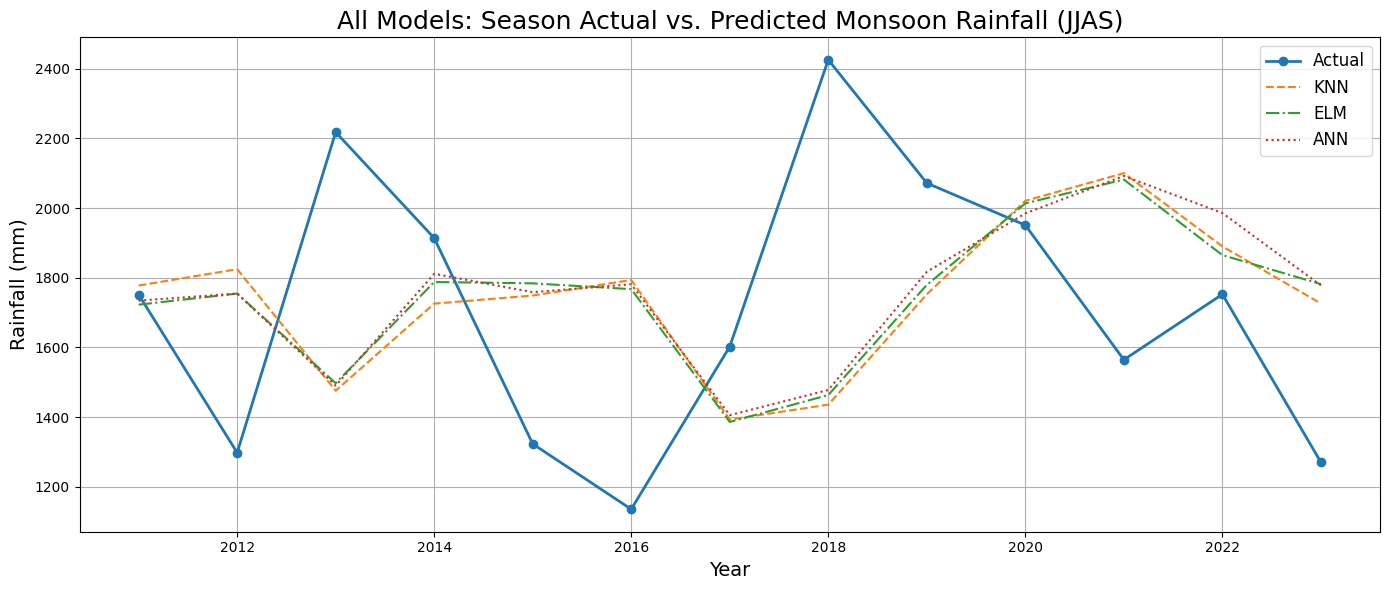

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


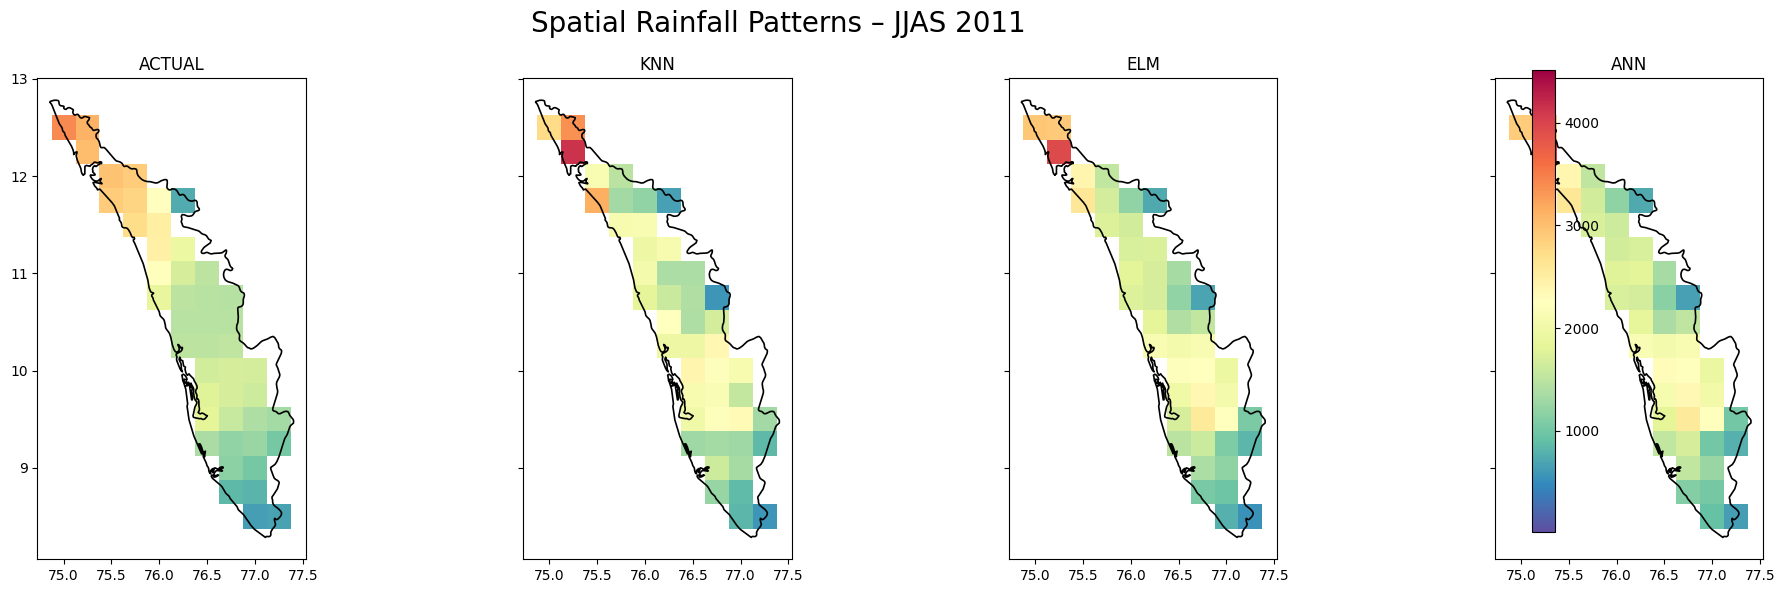

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


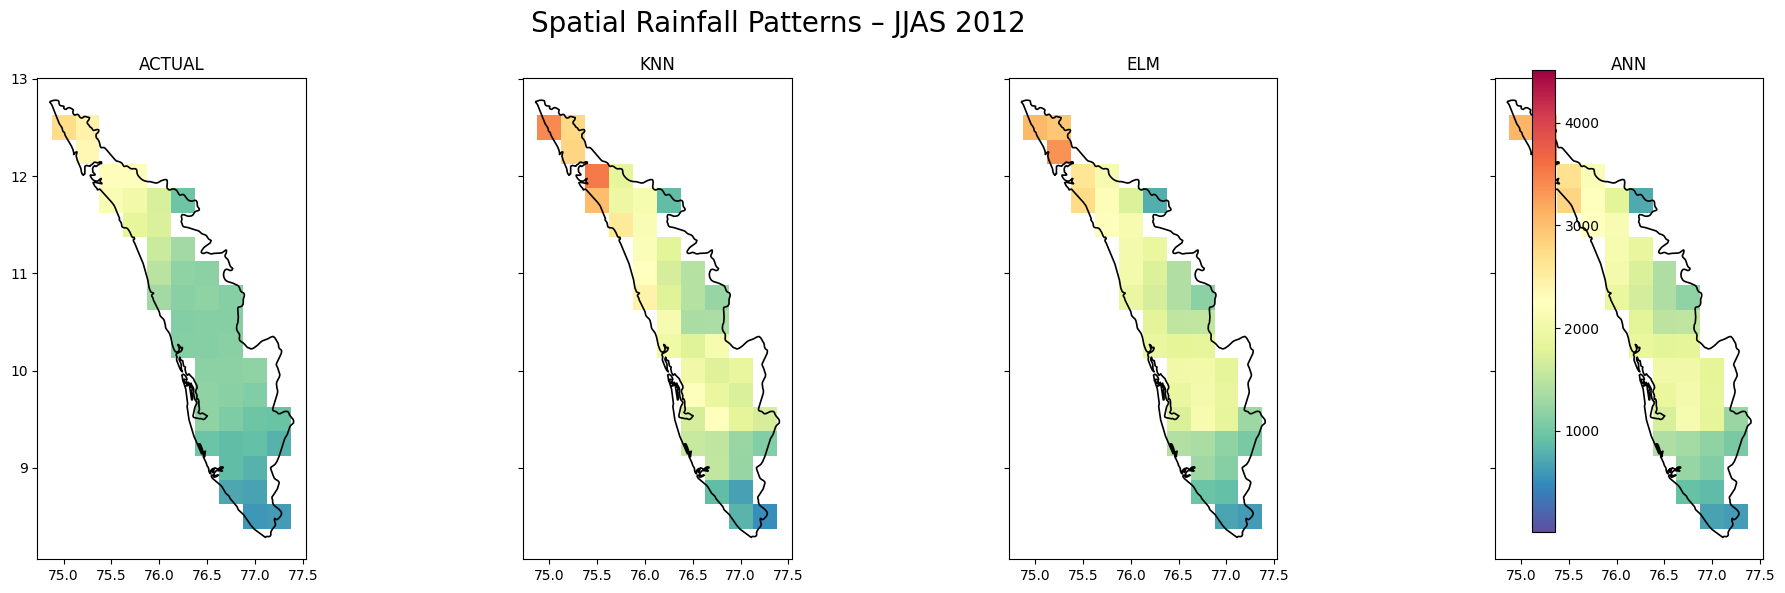

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


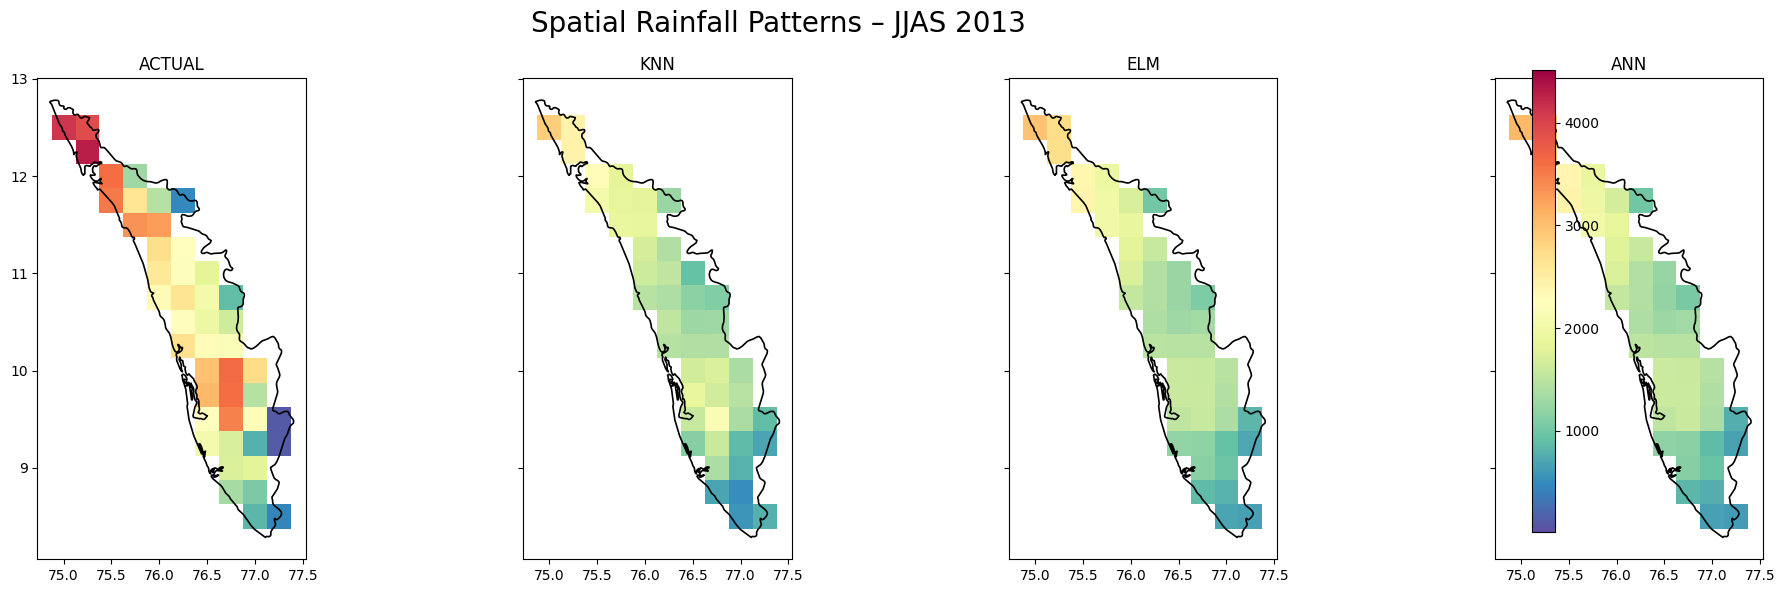

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


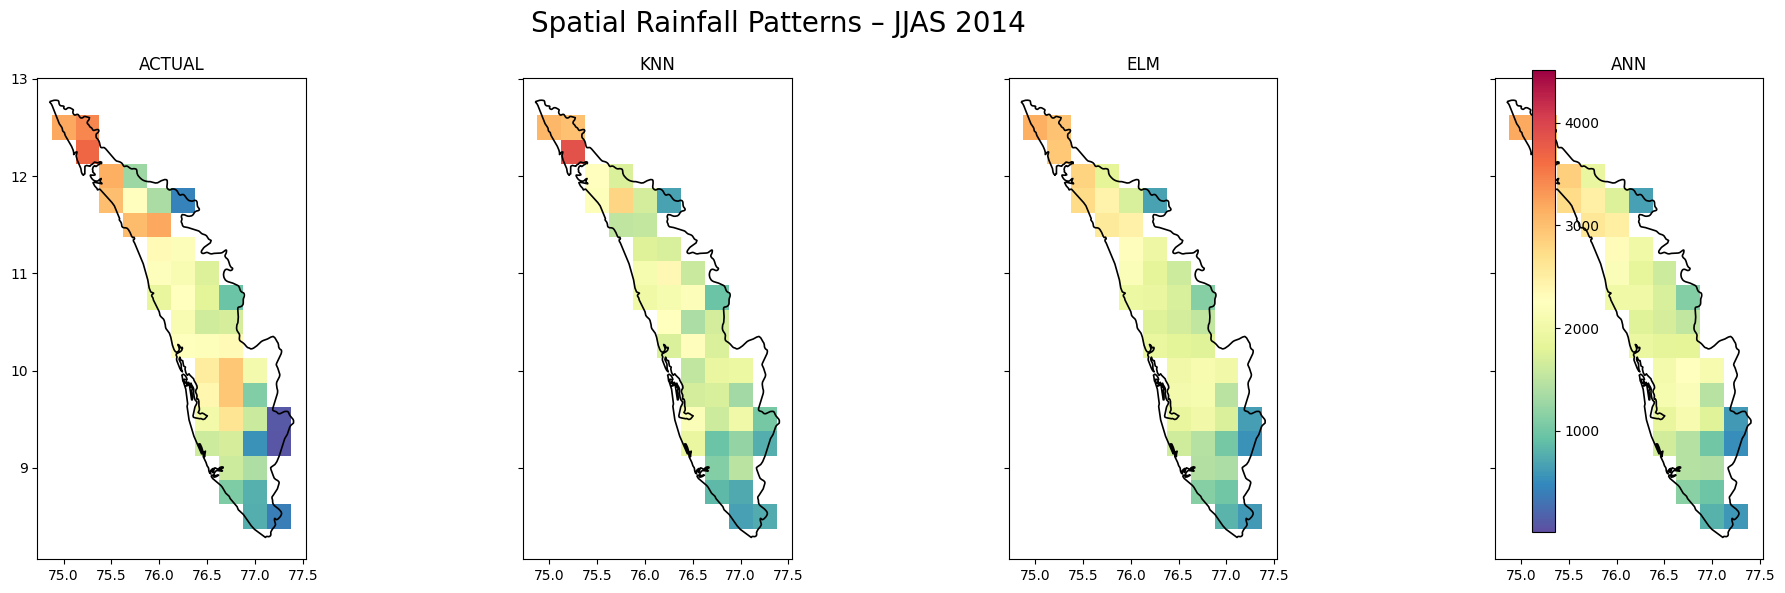

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


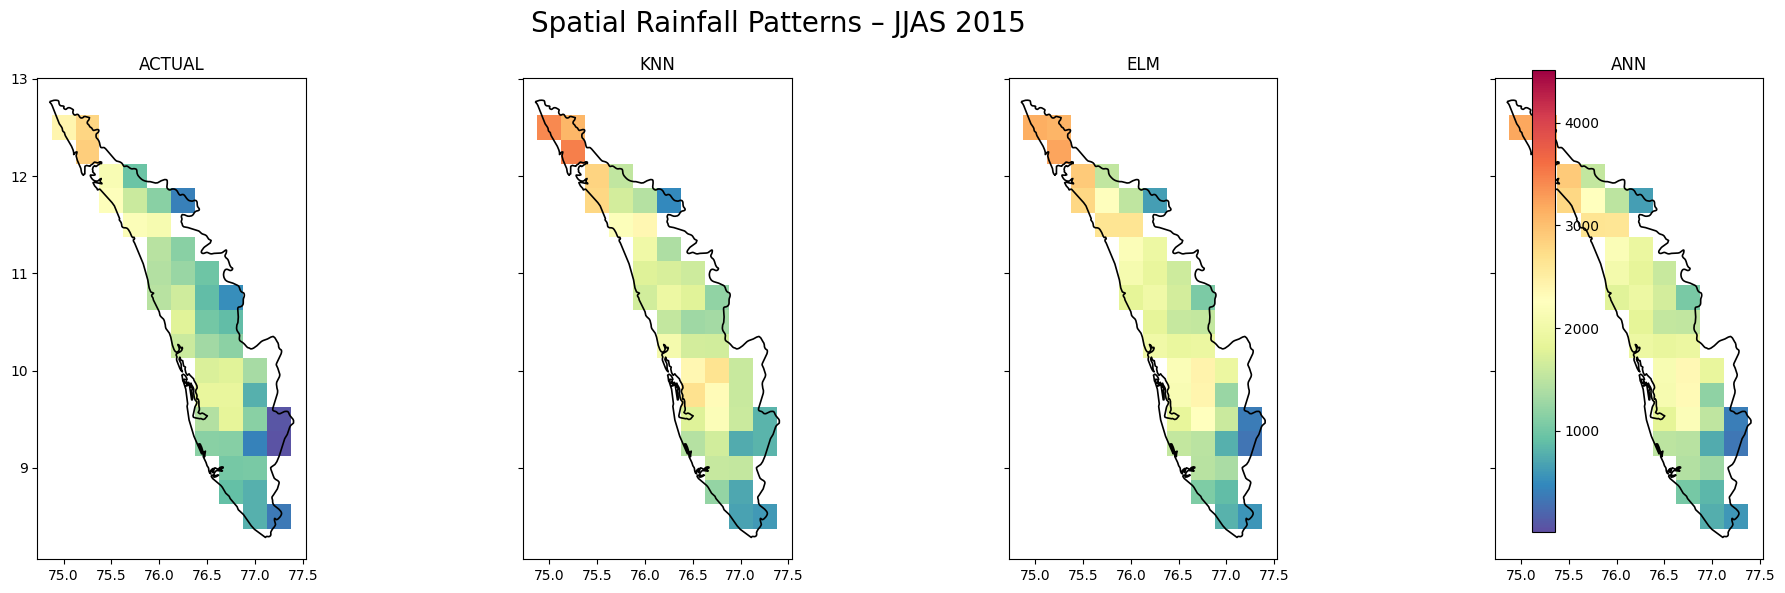

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


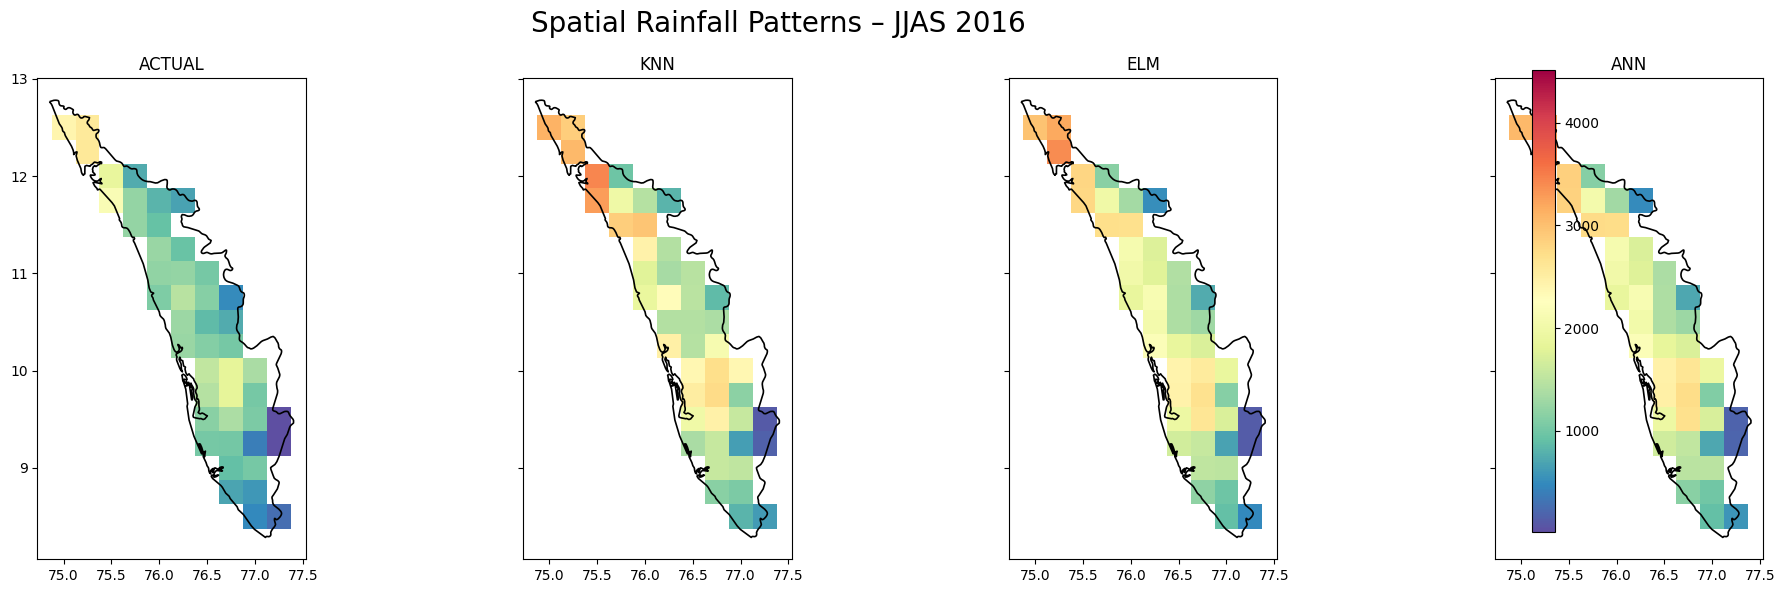

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


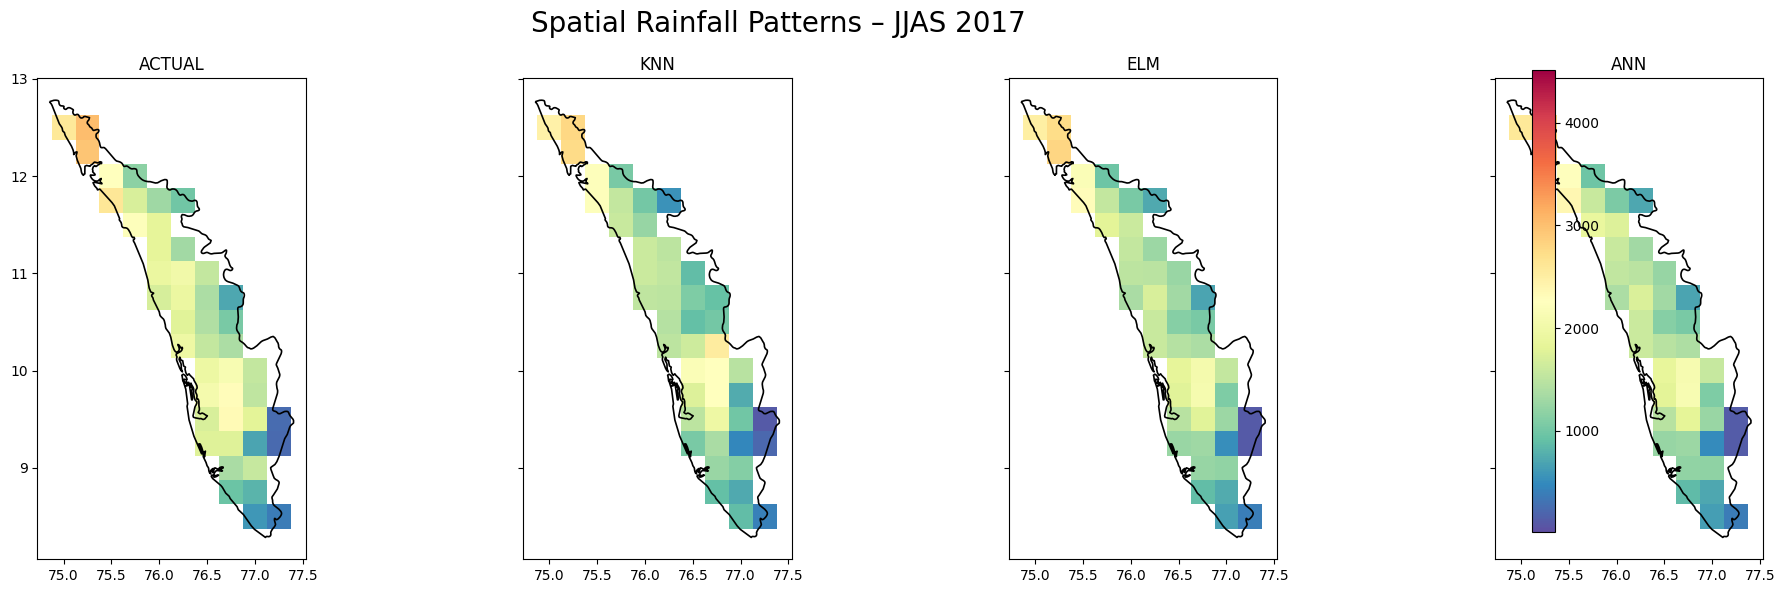

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


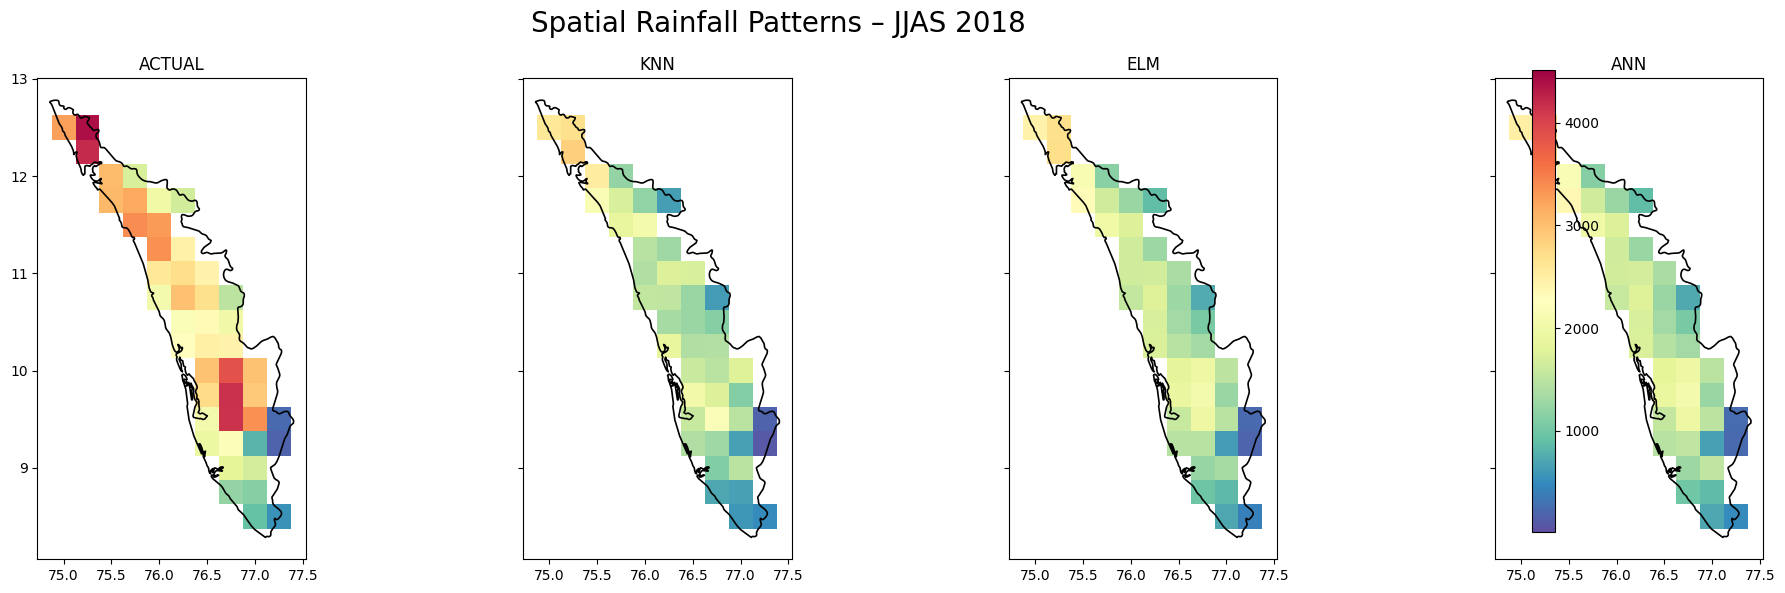

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


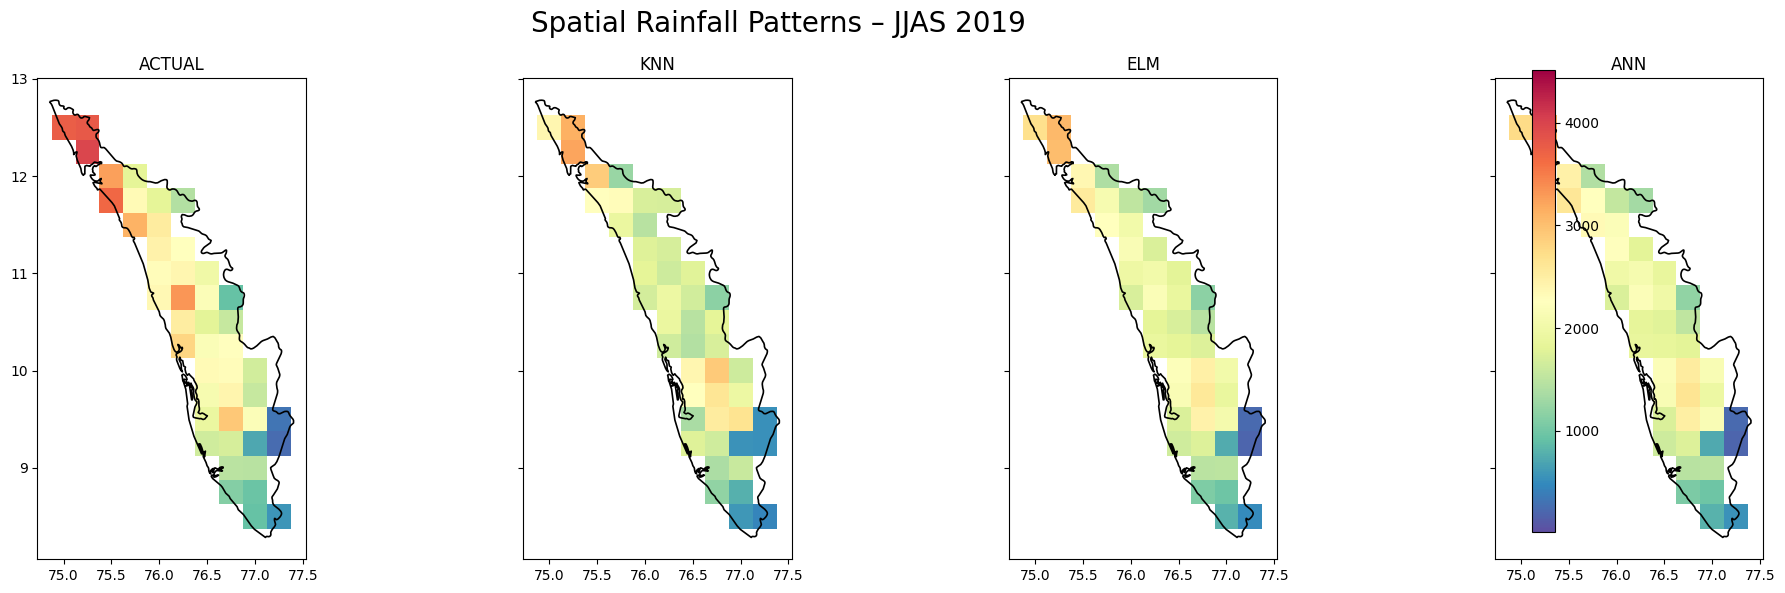

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


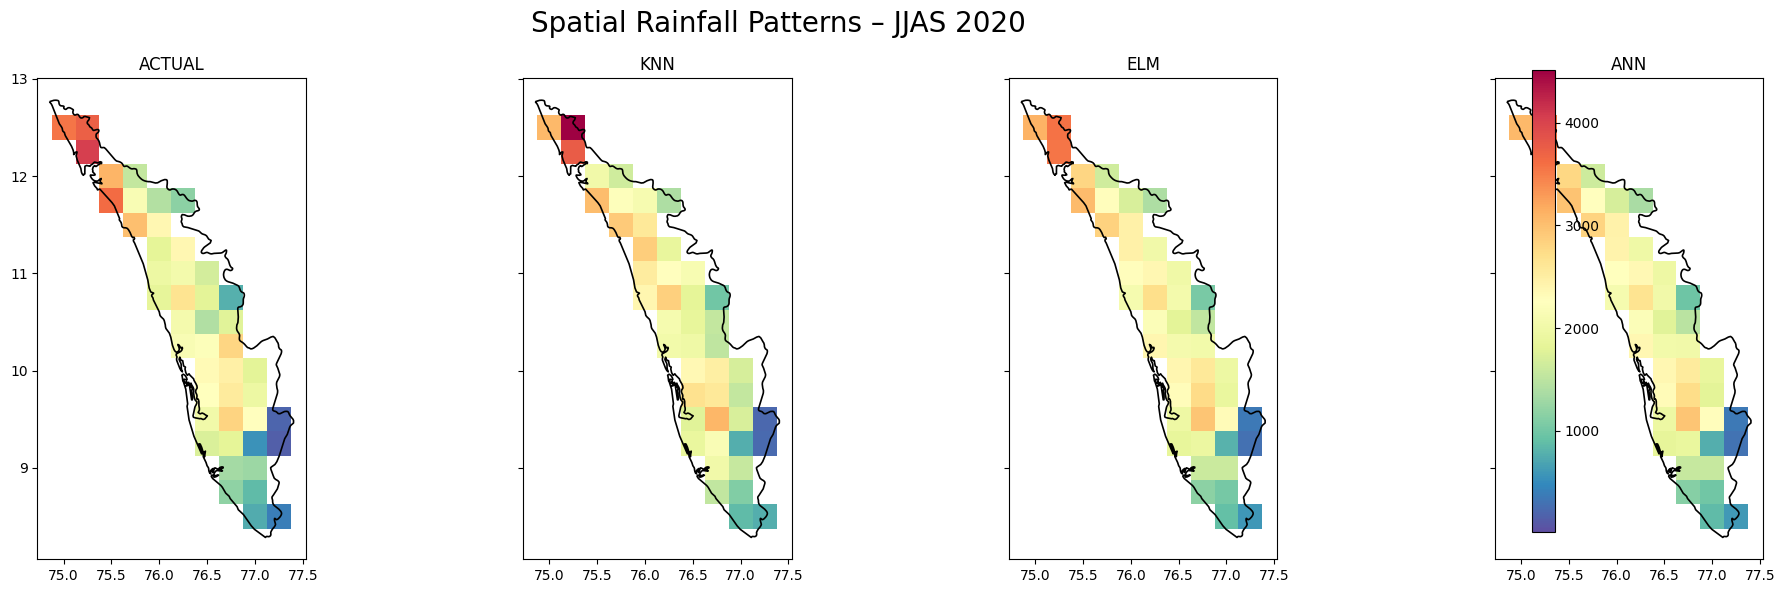

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


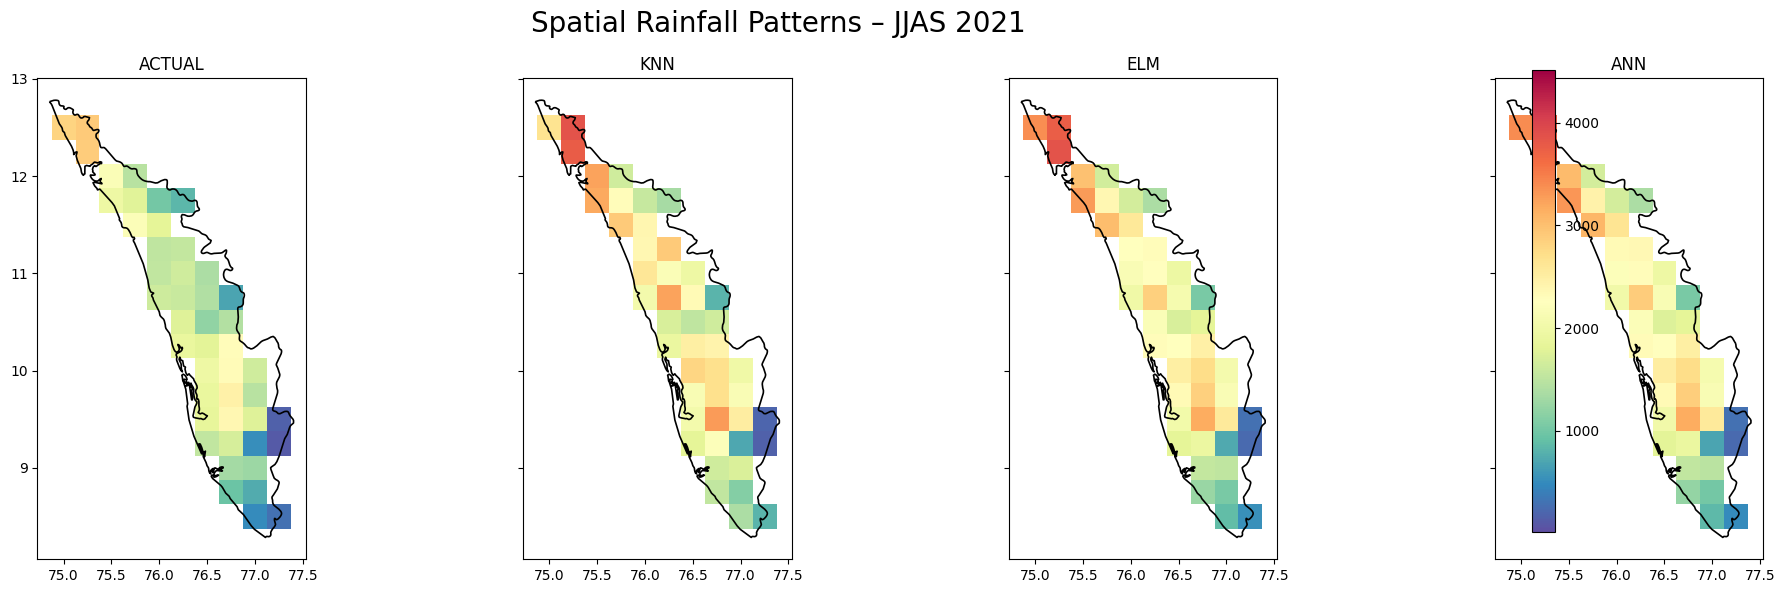

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


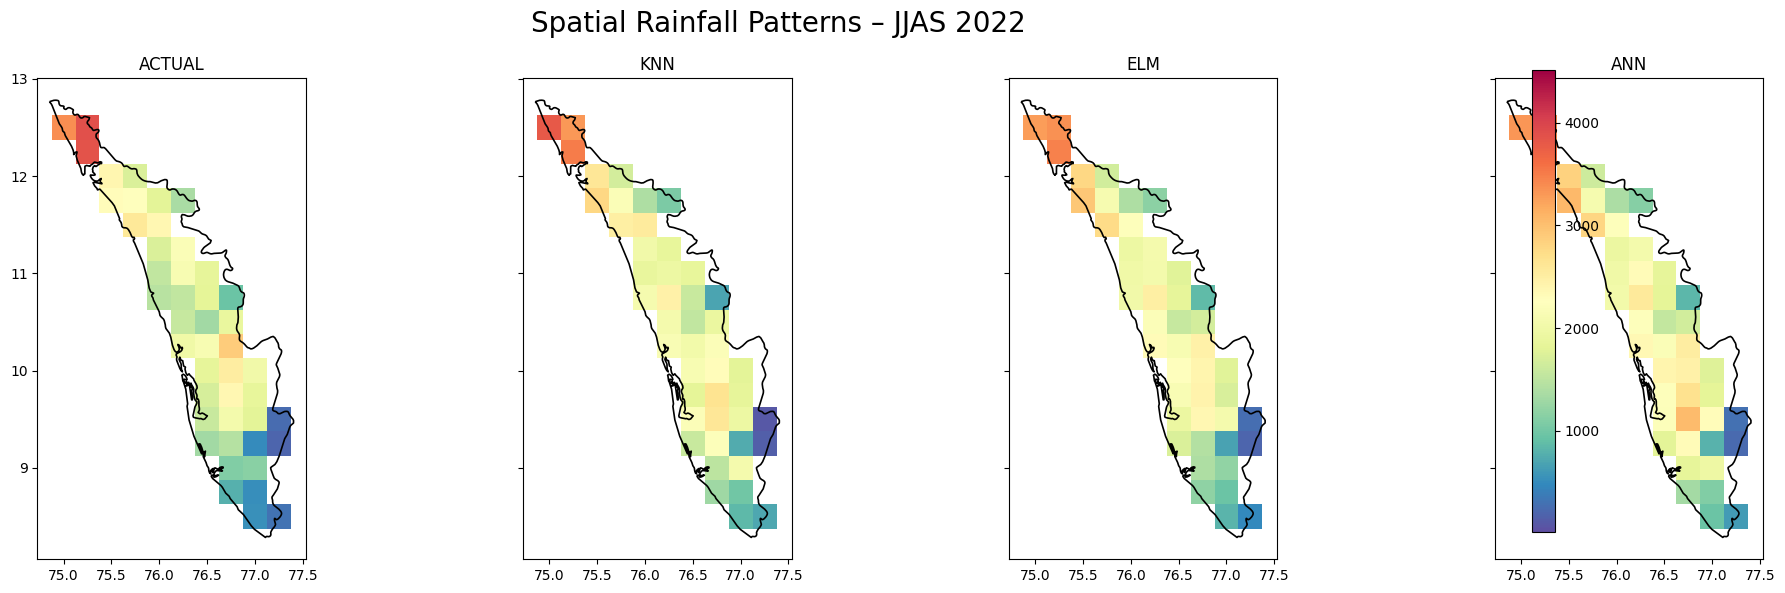

C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


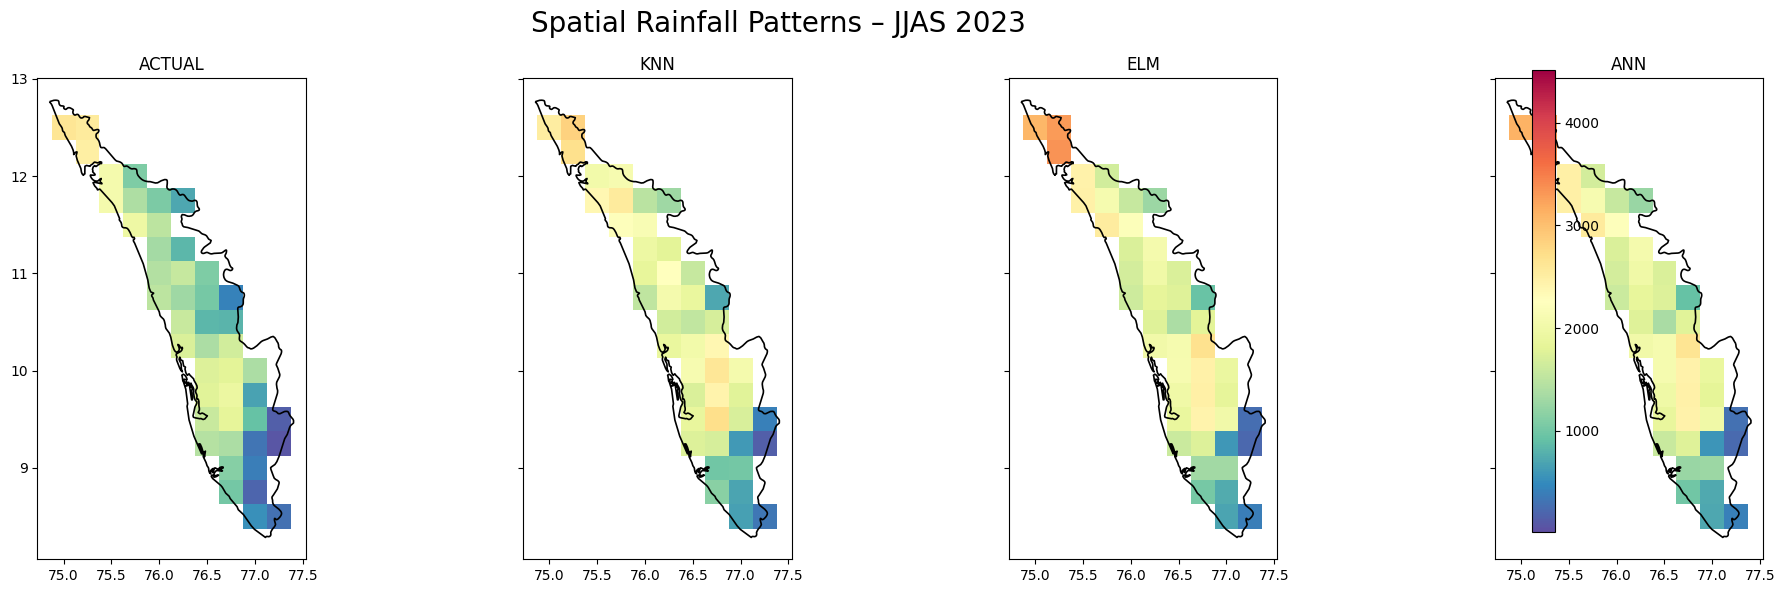


--- Spatial Accuracy Metrics for 2011 ---
  KNN:
    - Mean Absolute Error: 428.20 mm (24.4%)
    - Max Absolute Error:  1494.71 mm
  ELM:
    - Mean Absolute Error: 431.75 mm (24.6%)
    - Max Absolute Error:  1353.98 mm
  ANN:
    - Mean Absolute Error: 462.80 mm (26.4%)
    - Max Absolute Error:  1372.13 mm


C:\Users\rejoy\AppData\Local\Temp\ipykernel_20972\933055062.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


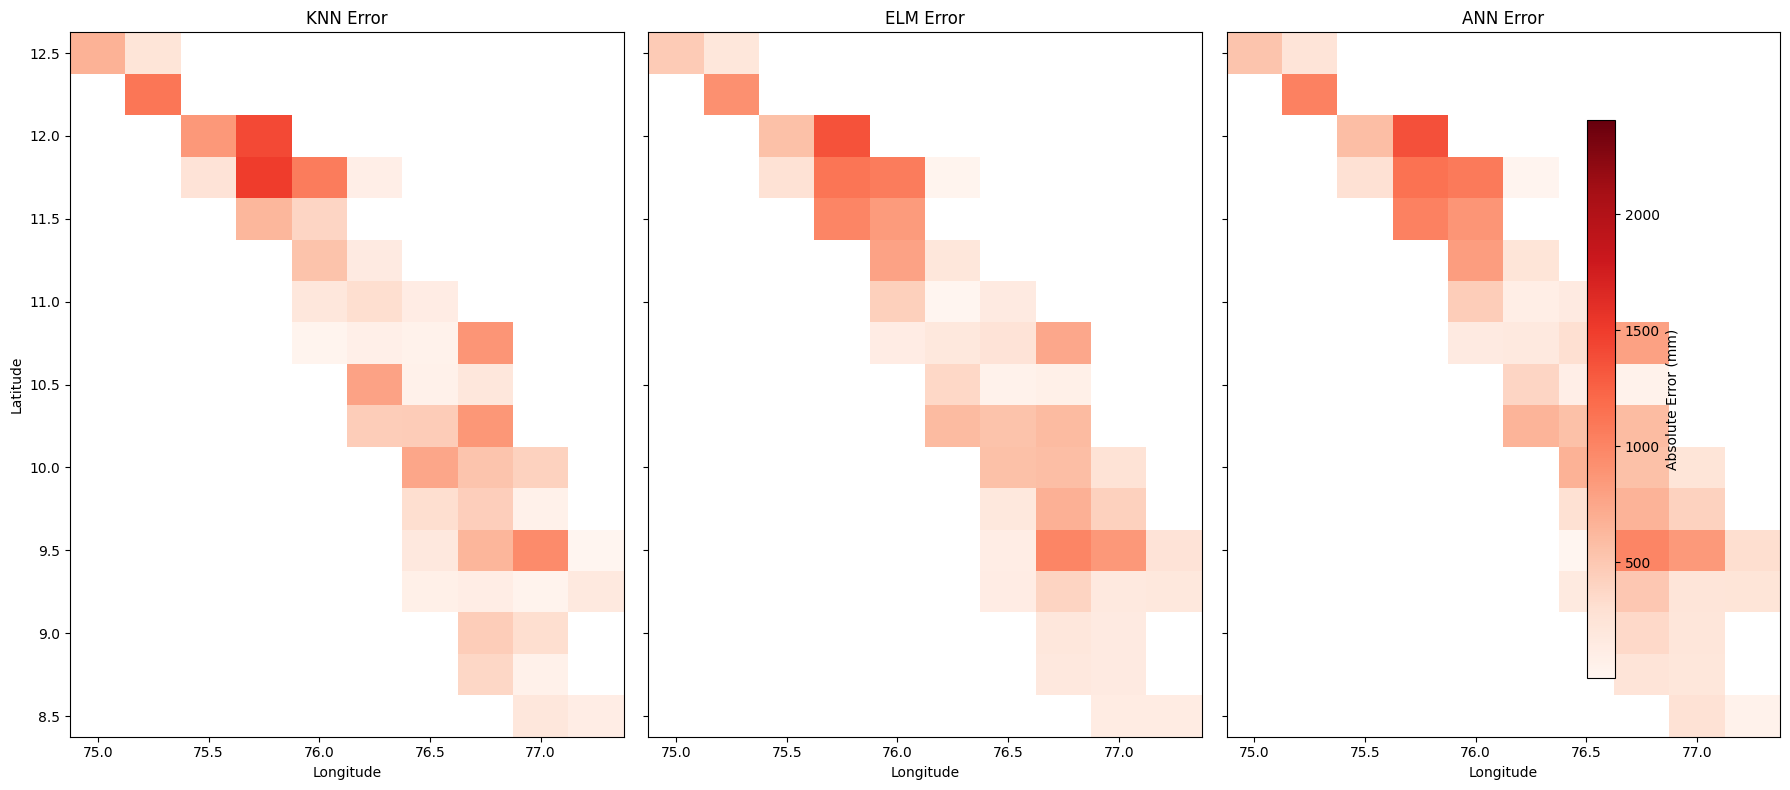


--- Spatial Accuracy Metrics for 2012 ---
  KNN:
    - Mean Absolute Error: 555.65 mm (42.8%)
    - Max Absolute Error:  1227.74 mm
  ELM:
    - Mean Absolute Error: 472.20 mm (36.4%)
    - Max Absolute Error:  1020.12 mm
  ANN:
    - Mean Absolute Error: 470.26 mm (36.2%)
    - Max Absolute Error:  1070.81 mm


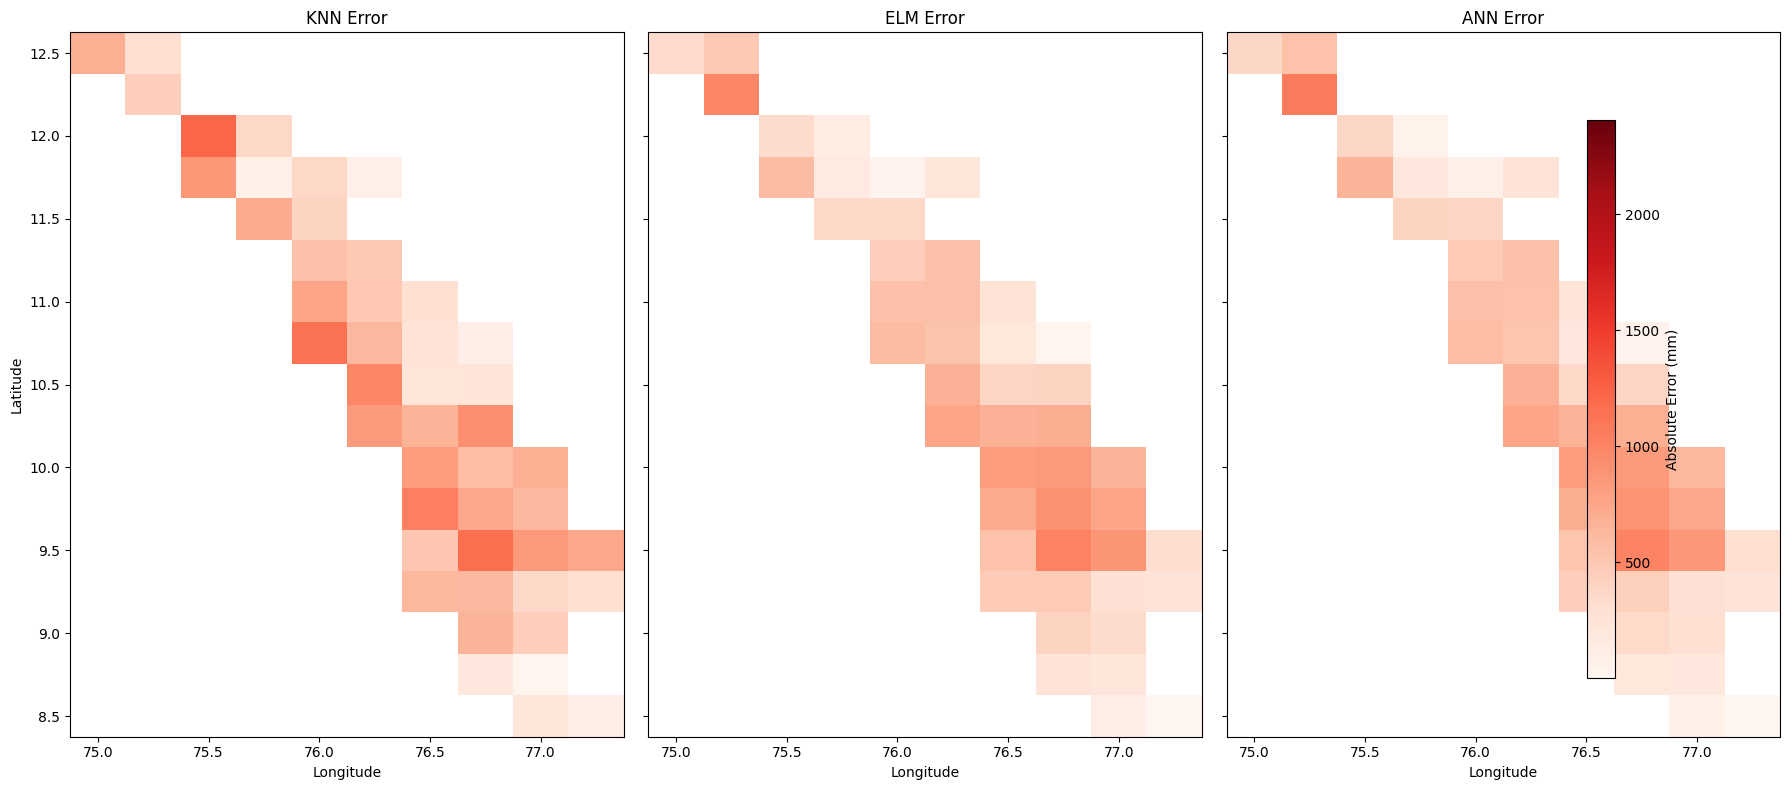


--- Spatial Accuracy Metrics for 2013 ---
  KNN:
    - Mean Absolute Error: 902.11 mm (40.7%)
    - Max Absolute Error:  1951.92 mm
  ELM:
    - Mean Absolute Error: 863.14 mm (38.9%)
    - Max Absolute Error:  2056.57 mm
  ANN:
    - Mean Absolute Error: 856.49 mm (38.6%)
    - Max Absolute Error:  2037.38 mm


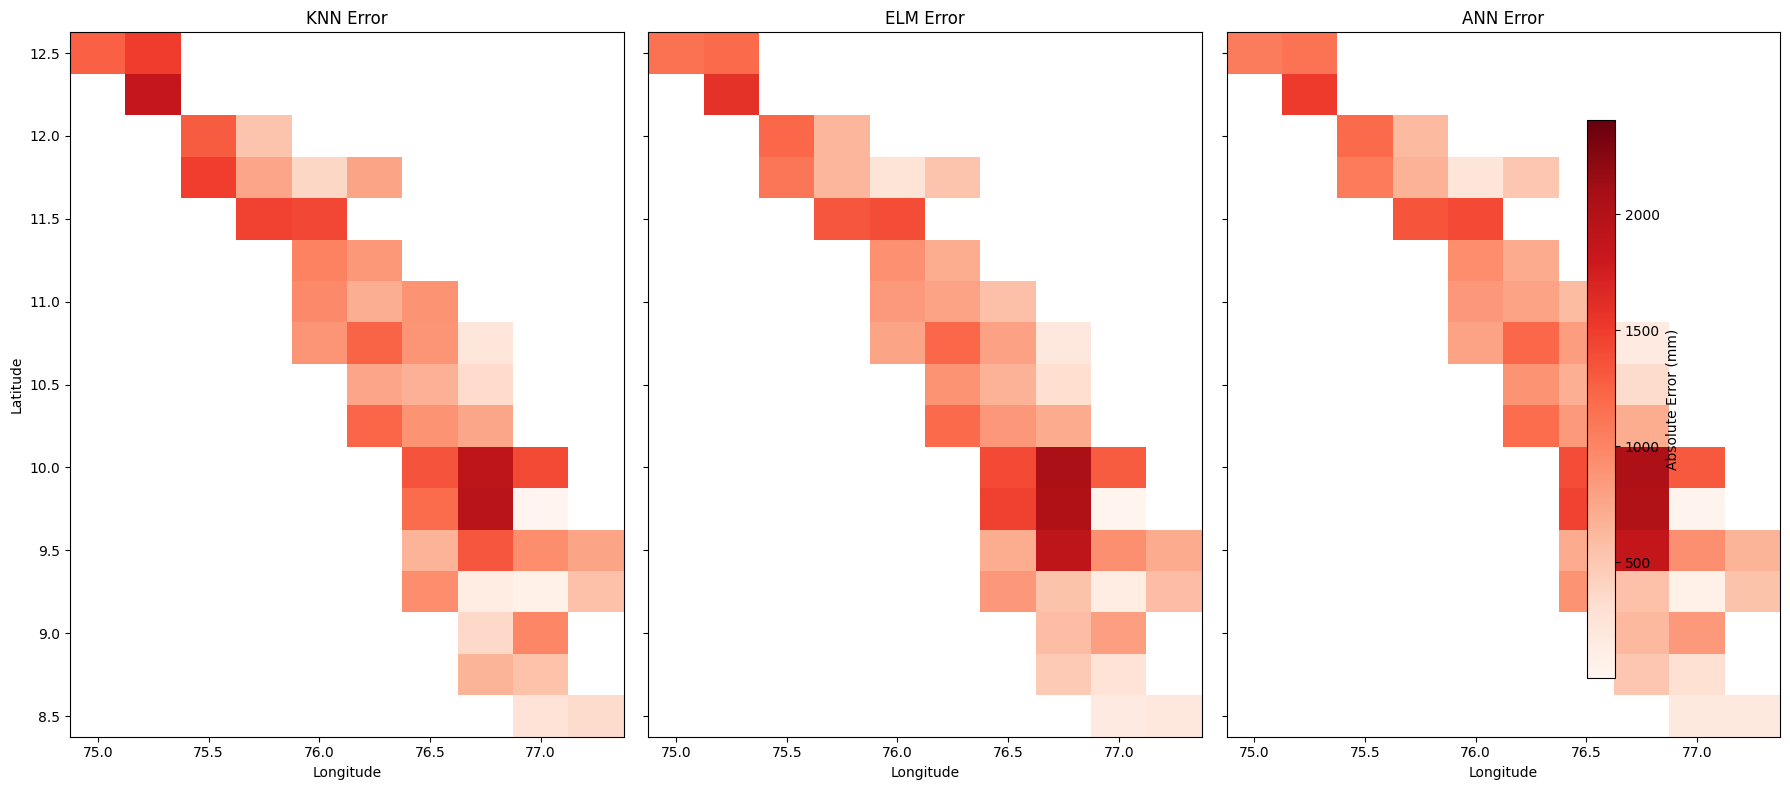


--- Spatial Accuracy Metrics for 2014 ---
  KNN:
    - Mean Absolute Error: 470.45 mm (24.6%)
    - Max Absolute Error:  1661.01 mm
  ELM:
    - Mean Absolute Error: 307.00 mm (16.0%)
    - Max Absolute Error:  868.75 mm
  ANN:
    - Mean Absolute Error: 289.17 mm (15.1%)
    - Max Absolute Error:  766.78 mm


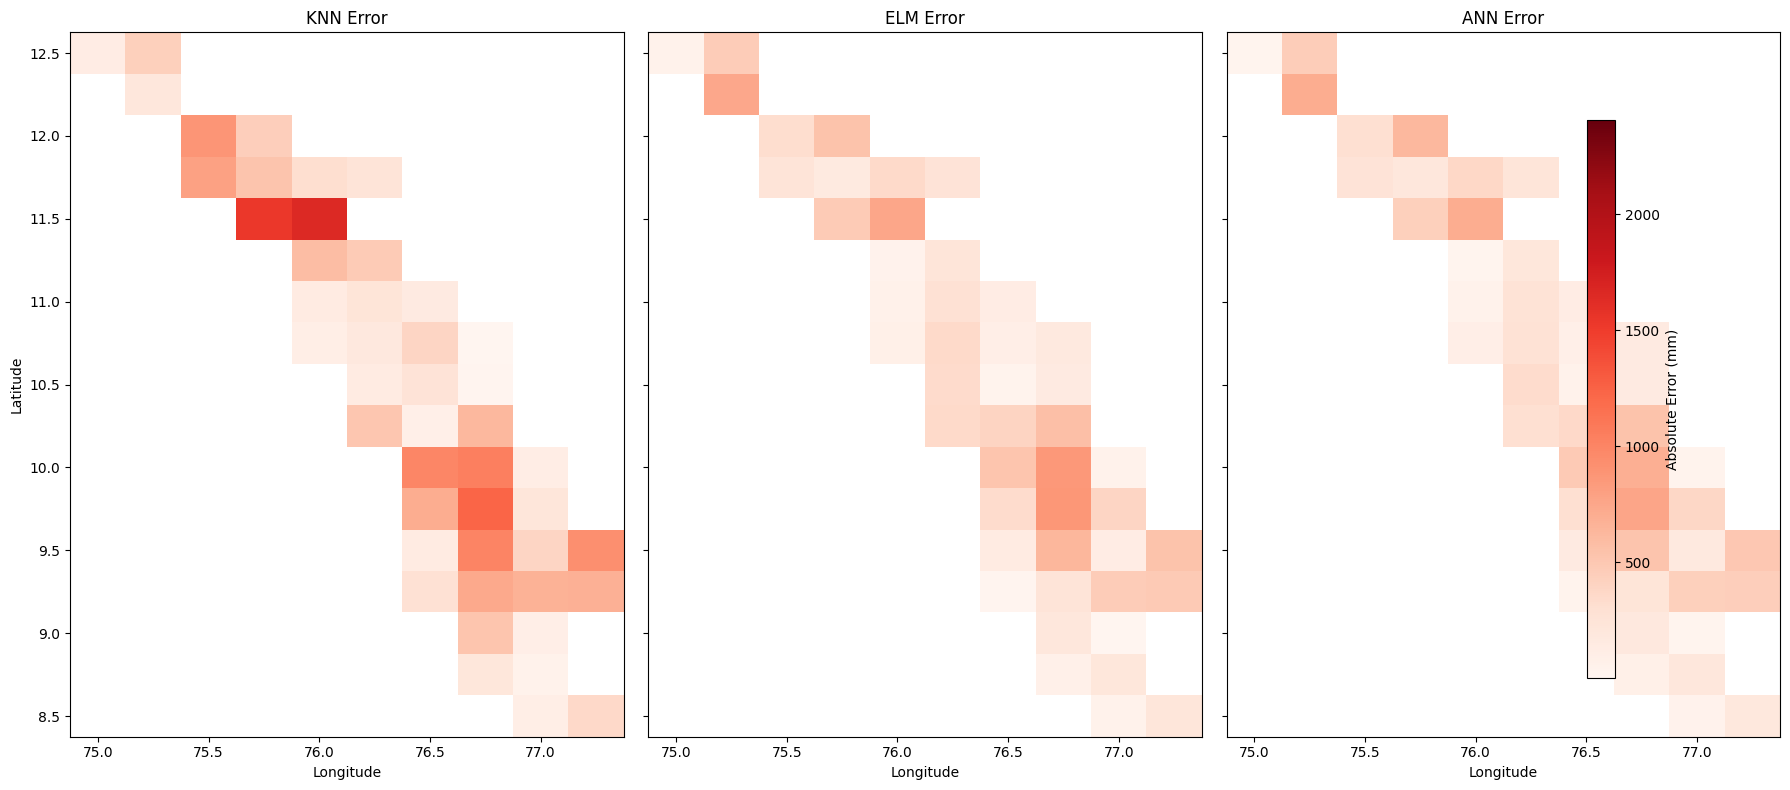


--- Spatial Accuracy Metrics for 2015 ---
  KNN:
    - Mean Absolute Error: 443.22 mm (33.5%)
    - Max Absolute Error:  992.98 mm
  ELM:
    - Mean Absolute Error: 461.16 mm (34.9%)
    - Max Absolute Error:  791.87 mm
  ANN:
    - Mean Absolute Error: 436.18 mm (33.0%)
    - Max Absolute Error:  782.11 mm


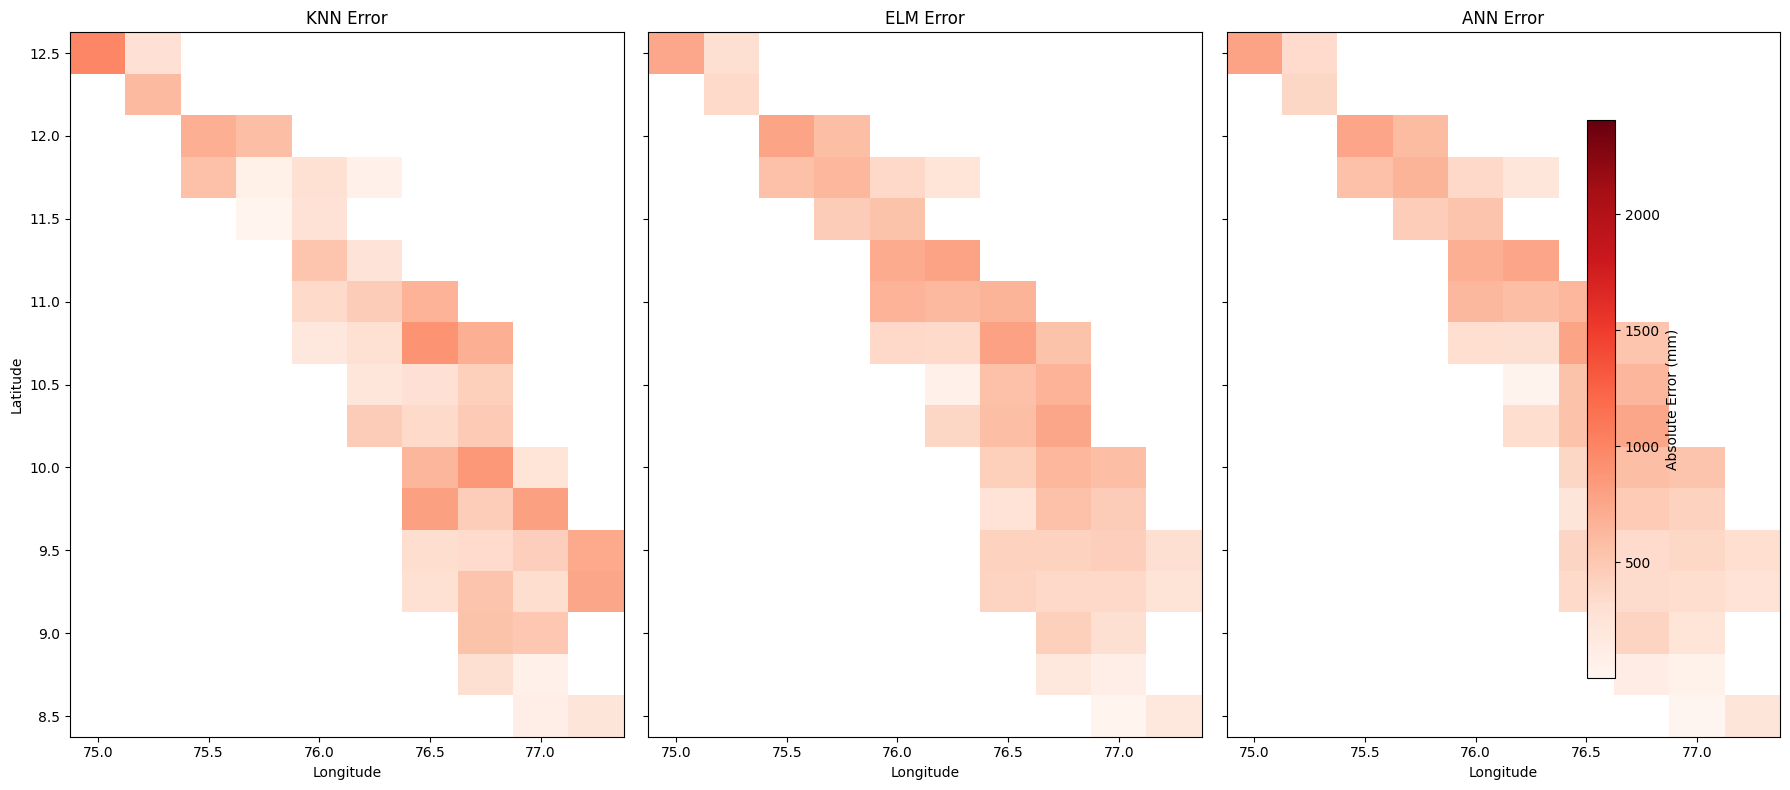


--- Spatial Accuracy Metrics for 2016 ---
  KNN:
    - Mean Absolute Error: 658.37 mm (58.0%)
    - Max Absolute Error:  2039.63 mm
  ELM:
    - Mean Absolute Error: 639.54 mm (56.3%)
    - Max Absolute Error:  1769.20 mm
  ANN:
    - Mean Absolute Error: 654.05 mm (57.6%)
    - Max Absolute Error:  1817.69 mm


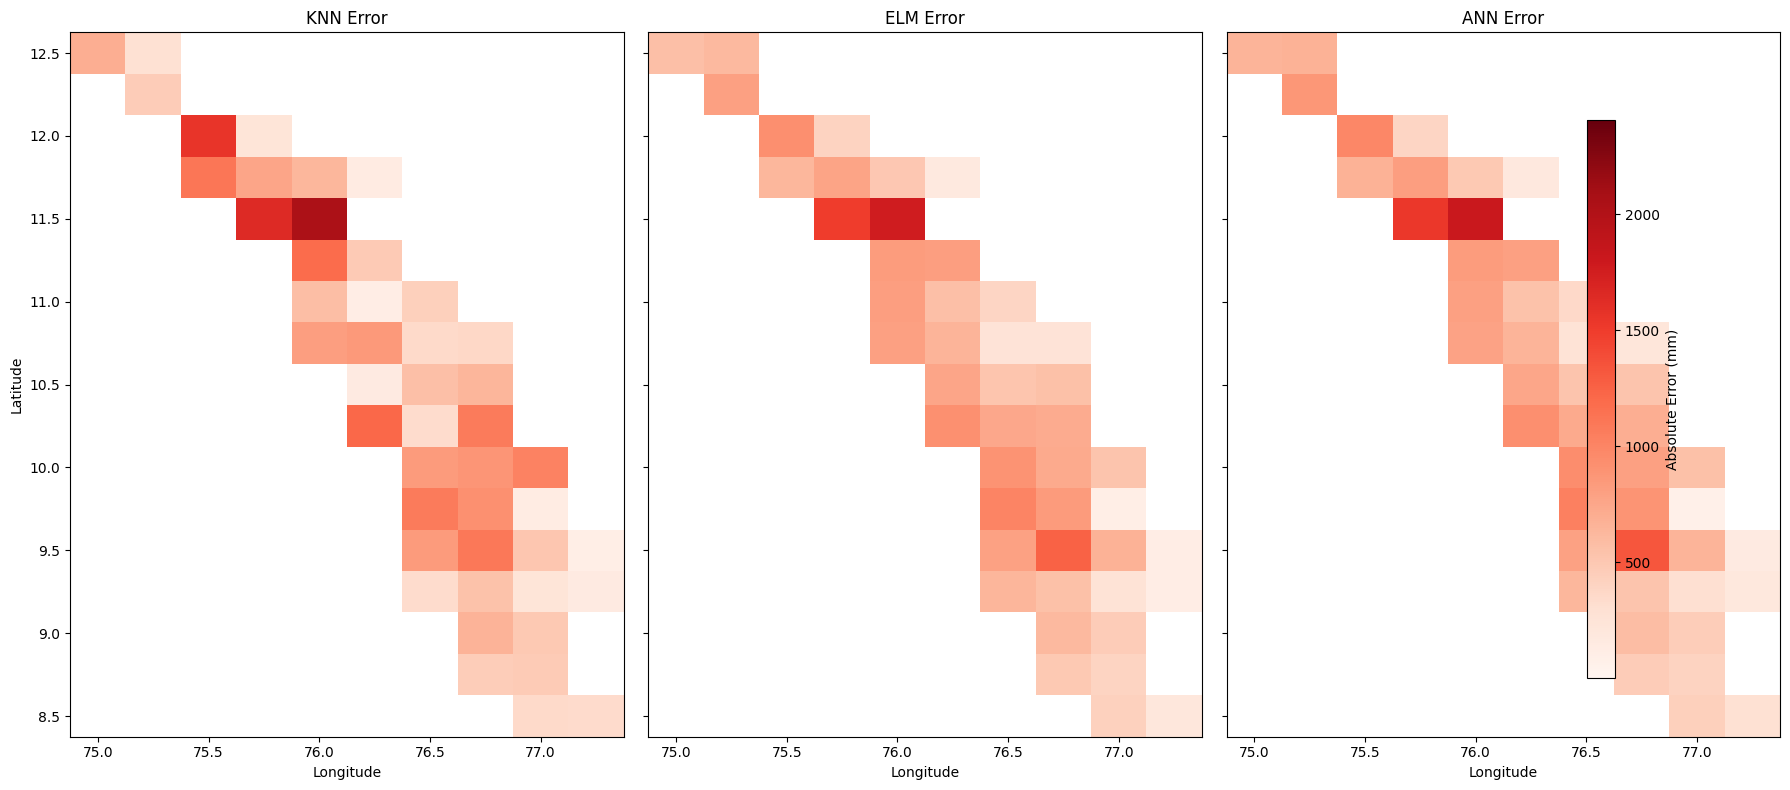


--- Spatial Accuracy Metrics for 2017 ---
  KNN:
    - Mean Absolute Error: 311.75 mm (19.5%)
    - Max Absolute Error:  1164.66 mm
  ELM:
    - Mean Absolute Error: 220.95 mm (13.8%)
    - Max Absolute Error:  568.90 mm
  ANN:
    - Mean Absolute Error: 202.37 mm (12.6%)
    - Max Absolute Error:  537.91 mm


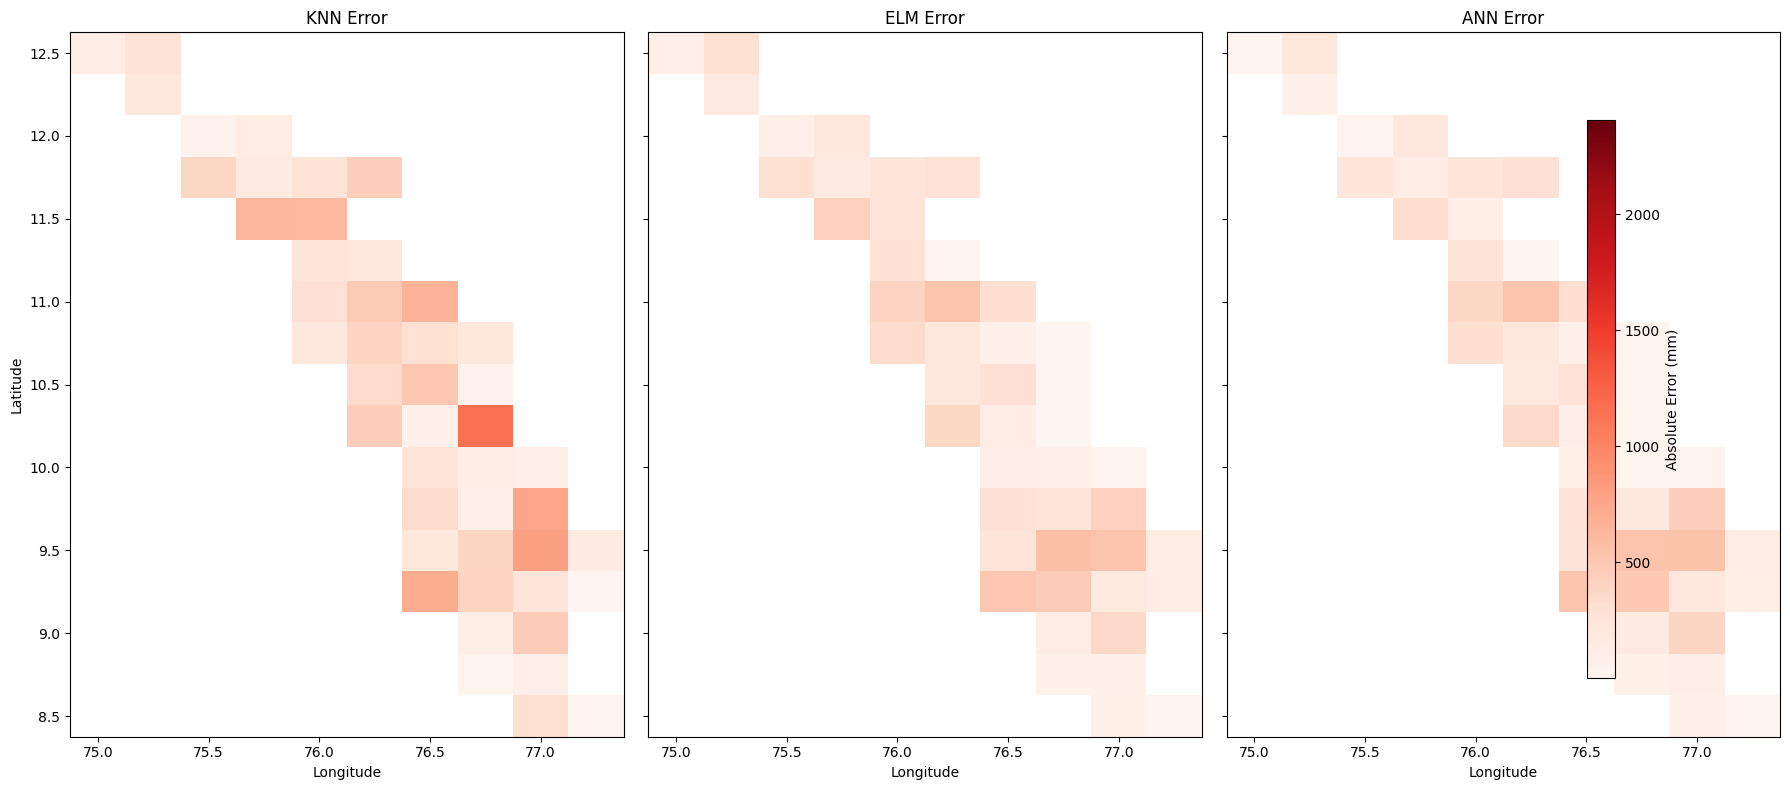


--- Spatial Accuracy Metrics for 2018 ---
  KNN:
    - Mean Absolute Error: 990.37 mm (40.8%)
    - Max Absolute Error:  2406.10 mm
  ELM:
    - Mean Absolute Error: 963.60 mm (39.7%)
    - Max Absolute Error:  2166.02 mm
  ANN:
    - Mean Absolute Error: 951.08 mm (39.2%)
    - Max Absolute Error:  2177.38 mm


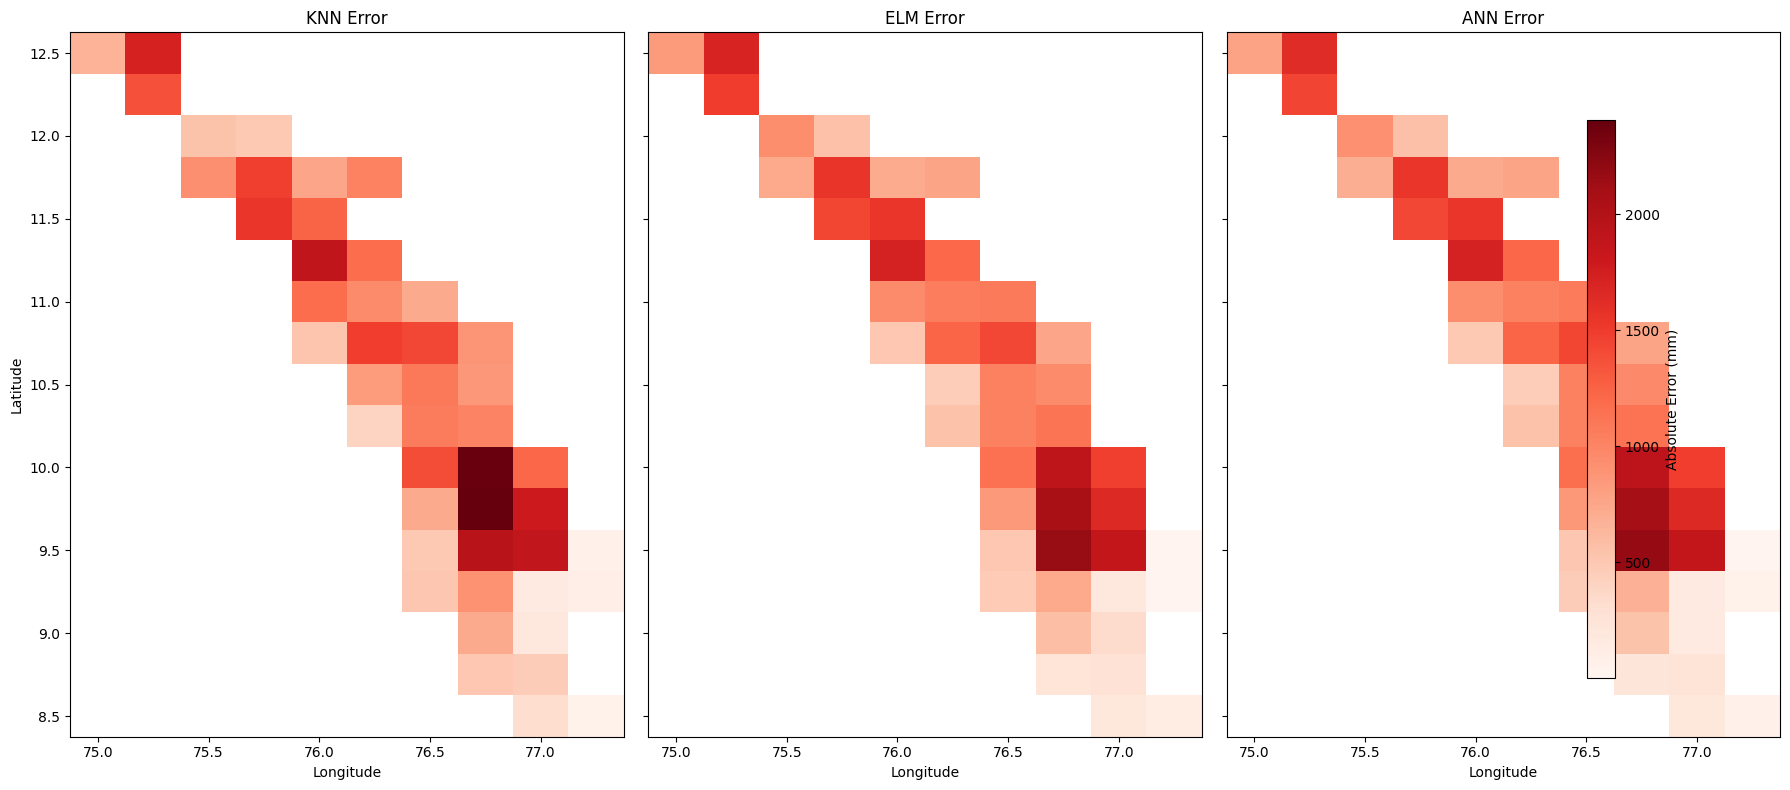


--- Spatial Accuracy Metrics for 2019 ---
  KNN:
    - Mean Absolute Error: 467.70 mm (22.6%)
    - Max Absolute Error:  1385.35 mm
  ELM:
    - Mean Absolute Error: 358.41 mm (17.3%)
    - Max Absolute Error:  1164.66 mm
  ANN:
    - Mean Absolute Error: 329.34 mm (15.9%)
    - Max Absolute Error:  1145.53 mm


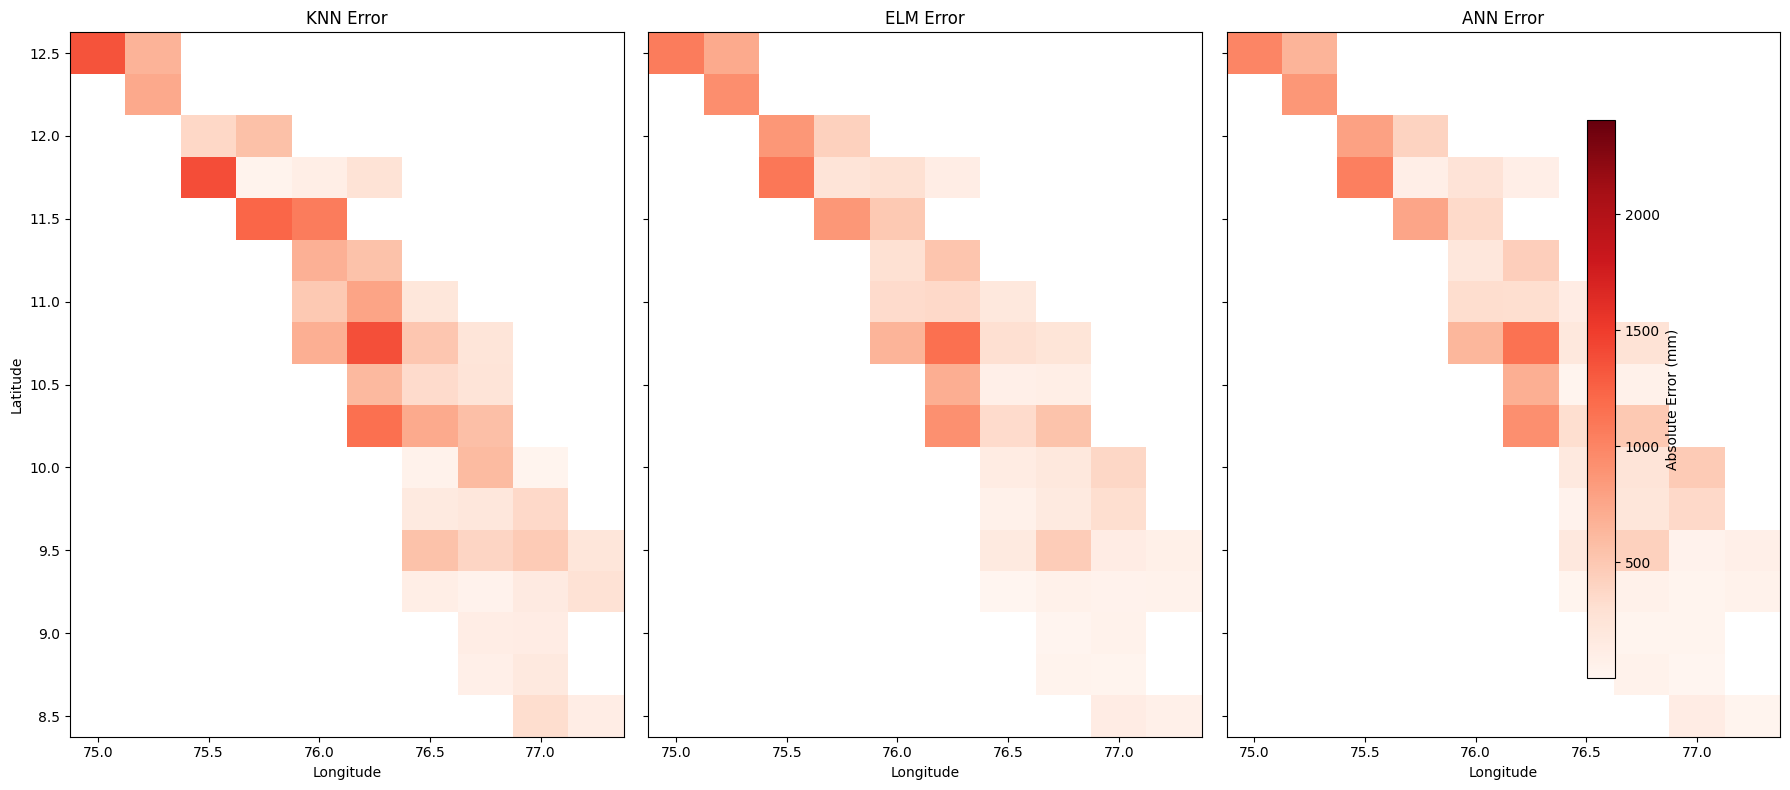


--- Spatial Accuracy Metrics for 2020 ---
  KNN:
    - Mean Absolute Error: 339.51 mm (17.4%)
    - Max Absolute Error:  1280.66 mm
  ELM:
    - Mean Absolute Error: 228.25 mm (11.7%)
    - Max Absolute Error:  768.90 mm
  ANN:
    - Mean Absolute Error: 220.65 mm (11.3%)
    - Max Absolute Error:  795.20 mm


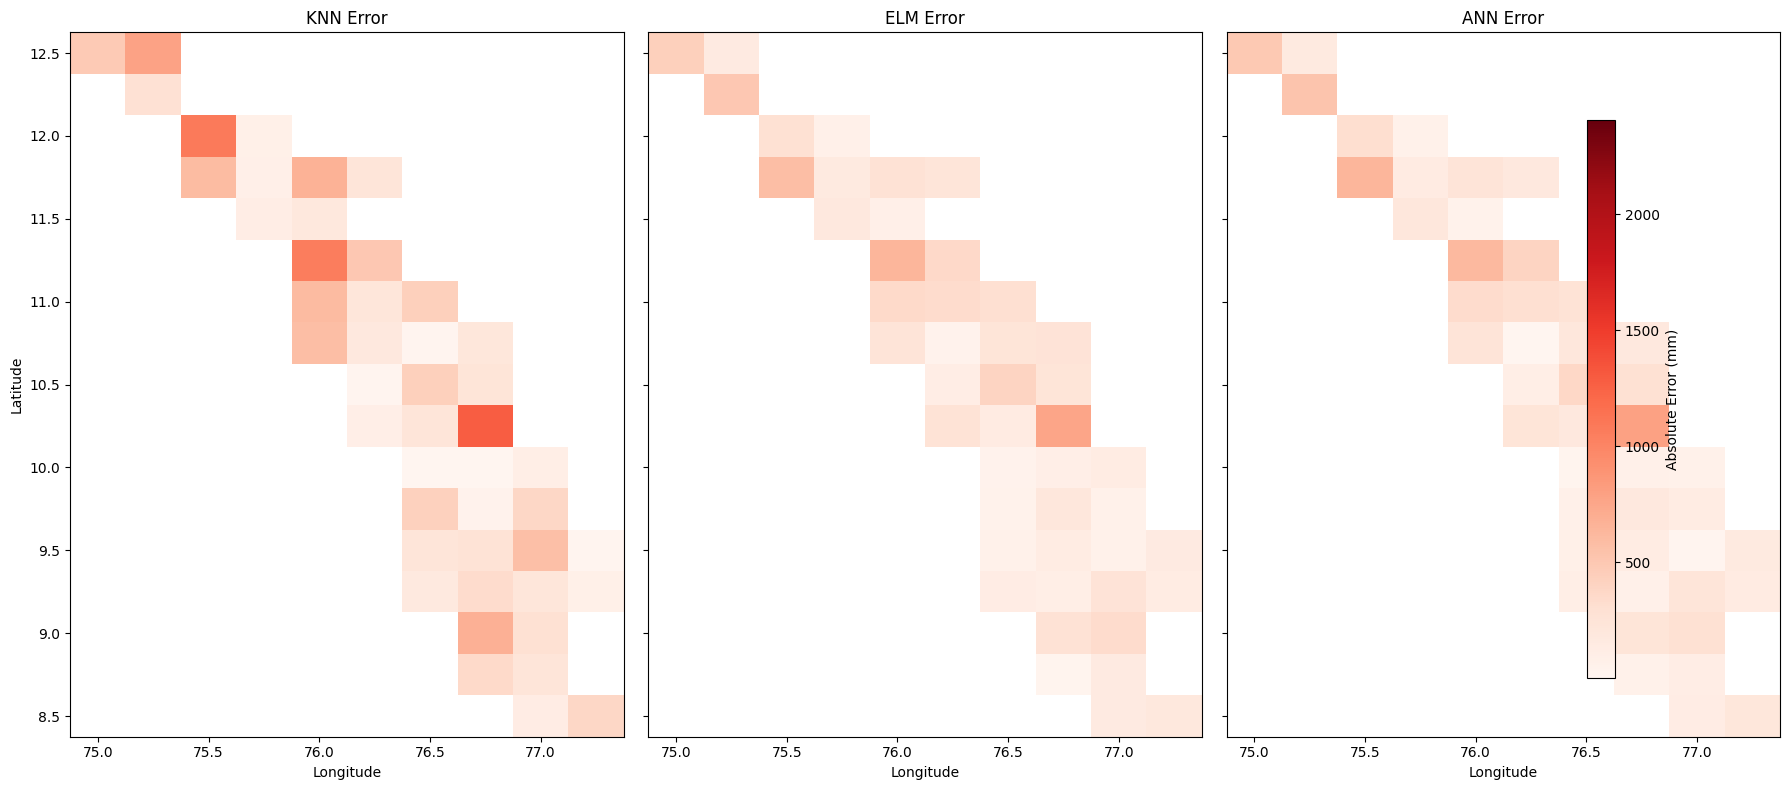


--- Spatial Accuracy Metrics for 2021 ---
  KNN:
    - Mean Absolute Error: 544.23 mm (34.8%)
    - Max Absolute Error:  1644.19 mm
  ELM:
    - Mean Absolute Error: 517.61 mm (33.1%)
    - Max Absolute Error:  1331.90 mm
  ANN:
    - Mean Absolute Error: 527.98 mm (33.7%)
    - Max Absolute Error:  1360.65 mm


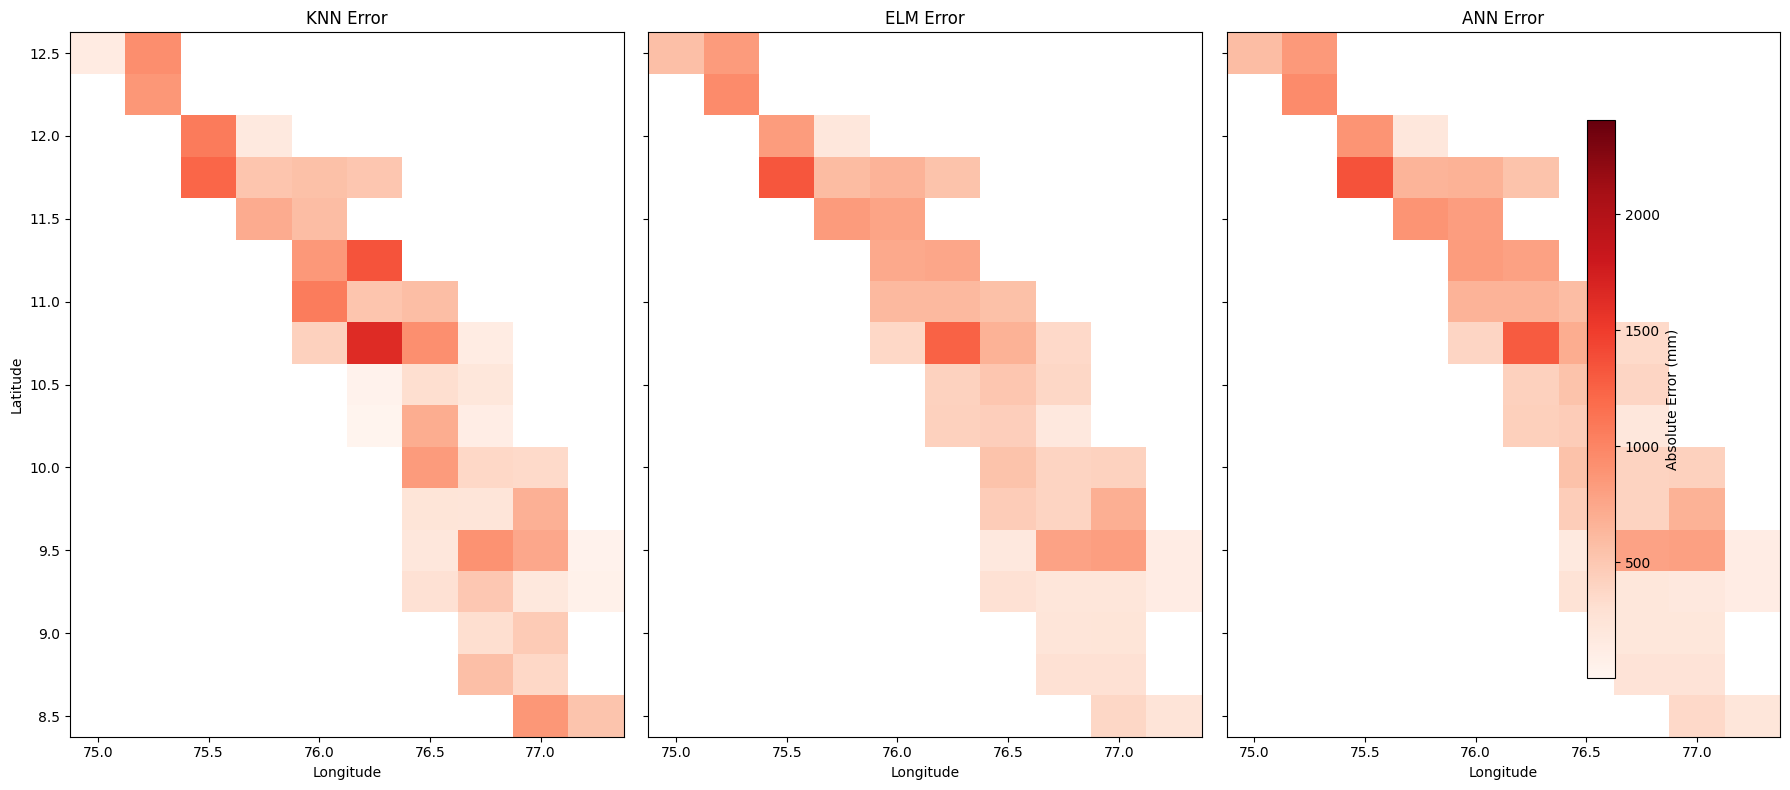


--- Spatial Accuracy Metrics for 2022 ---
  KNN:
    - Mean Absolute Error: 322.68 mm (18.4%)
    - Max Absolute Error:  926.25 mm
  ELM:
    - Mean Absolute Error: 263.62 mm (15.0%)
    - Max Absolute Error:  954.52 mm
  ANN:
    - Mean Absolute Error: 368.38 mm (21.0%)
    - Max Absolute Error:  1026.96 mm


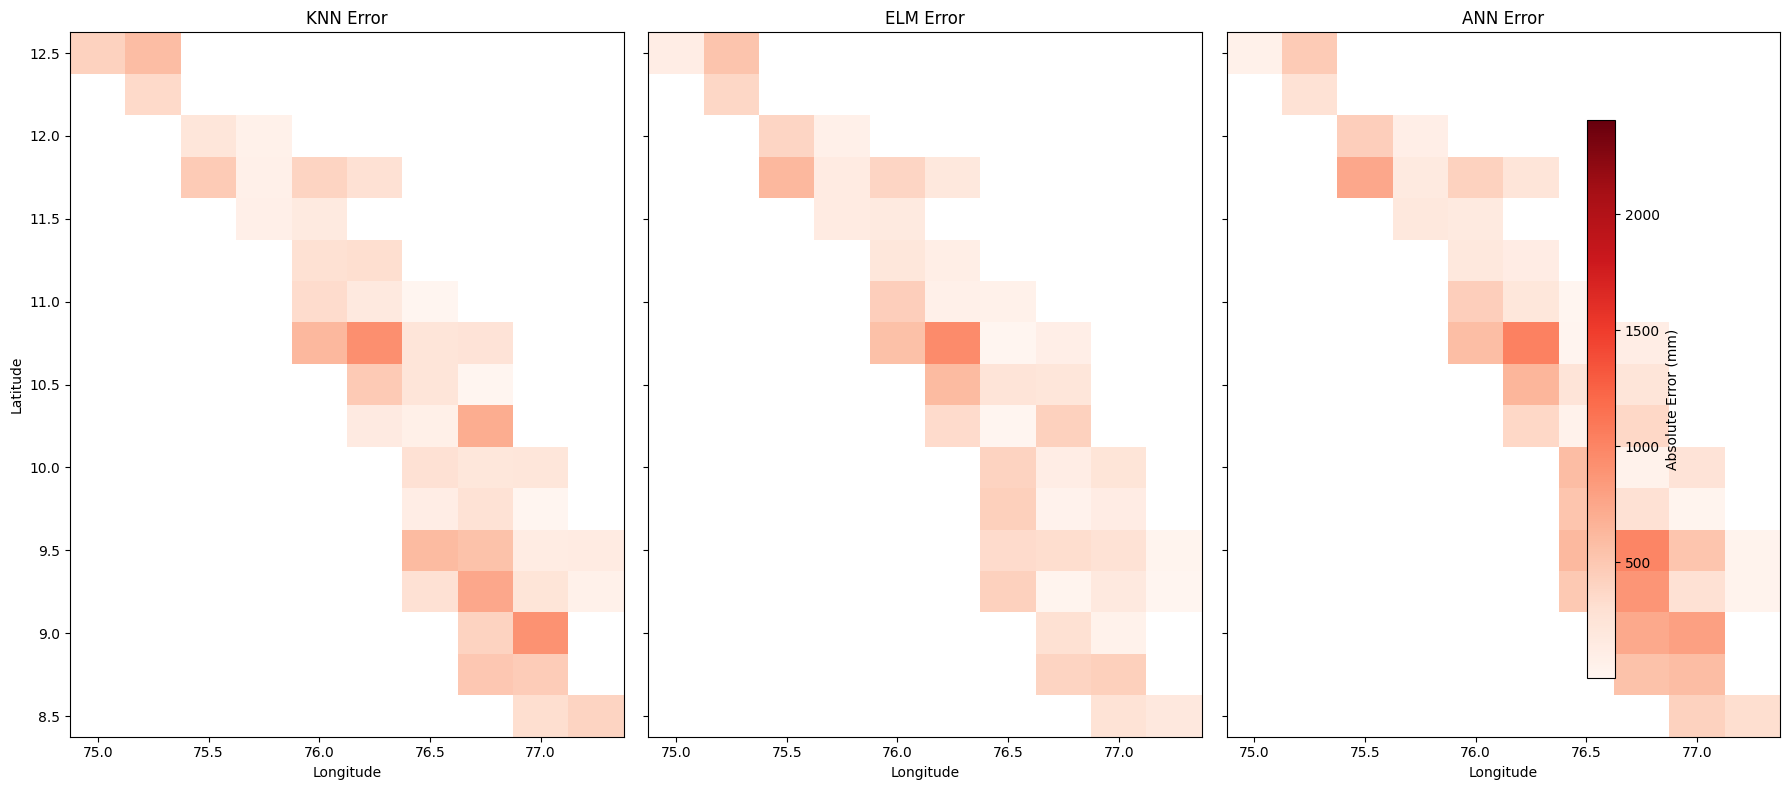


--- Spatial Accuracy Metrics for 2023 ---
  KNN:
    - Mean Absolute Error: 470.06 mm (37.0%)
    - Max Absolute Error:  1171.46 mm
  ELM:
    - Mean Absolute Error: 511.42 mm (40.3%)
    - Max Absolute Error:  1231.33 mm
  ANN:
    - Mean Absolute Error: 508.89 mm (40.1%)
    - Max Absolute Error:  1234.38 mm


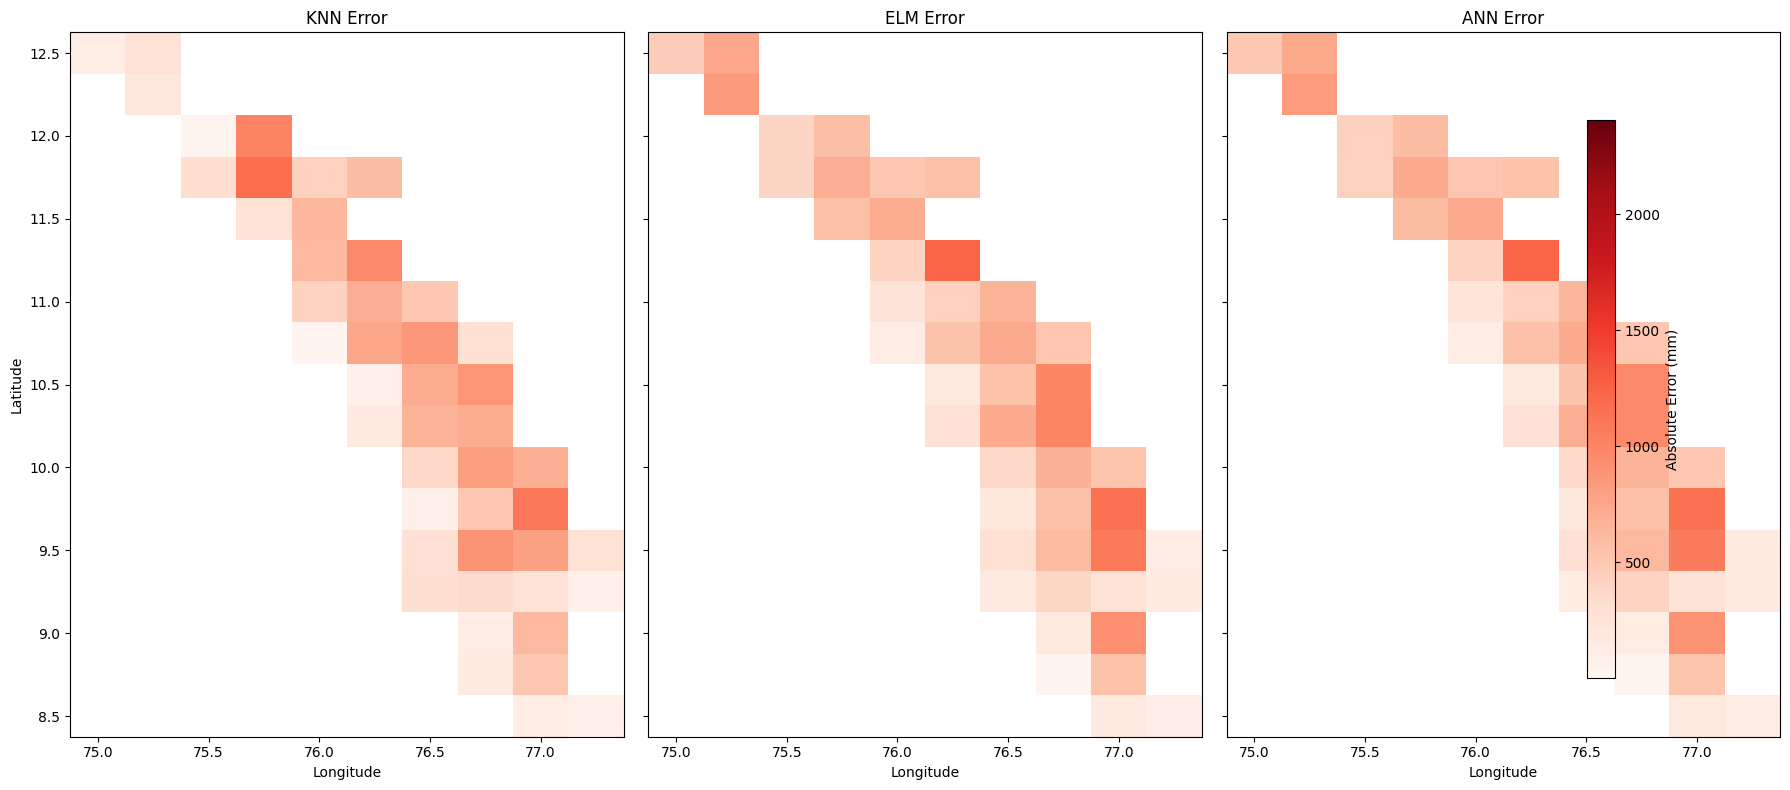

In [3]:
# Visualization functions: time-series, spatial maps, and spatial error plots for JJAS
def visualize_results(test_meta_df, y_true_orig, y_pred_knn, y_pred_elm, y_pred_ann):
    """Create time-series visualizations with correct temporal alignment."""
    plot_df = test_meta_df.copy()
    plot_df['ACTUAL'] = y_true_orig
    plot_df['KNN_PRED'] = y_pred_knn
    plot_df['ELM_PRED'] = y_pred_elm
    plot_df['ANN_PRED'] = y_pred_ann
    # Predictions correspond to the same YEAR as the targets
    plot_df['PRED_YEAR'] = plot_df['YEAR']
    actual_yearly = plot_df.groupby('YEAR')['ACTUAL'].mean()
    knn_yearly = plot_df.groupby('PRED_YEAR')['KNN_PRED'].mean()
    elm_yearly = plot_df.groupby('PRED_YEAR')['ELM_PRED'].mean()
    ann_yearly = plot_df.groupby('PRED_YEAR')['ANN_PRED'].mean()
    plt.figure(figsize=(14, 6))
    plt.plot(actual_yearly.index, actual_yearly.values, label='Actual', marker='o', linewidth=2)
    plt.plot(knn_yearly.index, knn_yearly.values, label='KNN', linestyle='--')
    plt.plot(elm_yearly.index, elm_yearly.values, label='ELM', linestyle='-.')
    plt.plot(ann_yearly.index, ann_yearly.values, label='ANN', linestyle=':')
    plt.title('All Models: Season Actual vs. Predicted Monsoon Rainfall (JJAS)', fontsize=18)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Rainfall (mm)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def visualize_spatial_predictions(test_meta_df, y_true, y_pred_knn, y_pred_elm, y_pred_ann, kerala_shape):
    """Spatial rainfall maps with temporal alignment:
    - ACTUAL at YEAR
    - Predictions at same YEAR
    """
    results_df = test_meta_df.copy()
    results_df['ACTUAL'] = y_true
    results_df['KNN'] = y_pred_knn
    results_df['ELM'] = y_pred_elm
    results_df['ANN'] = y_pred_ann
    results_df['PRED_YEAR'] = results_df['YEAR']
    models_pred = ['KNN', 'ELM', 'ANN']
    all_values = np.concatenate([results_df['ACTUAL'].values.flatten(), results_df['KNN'].values.flatten(), results_df['ELM'].values.flatten(), results_df['ANN'].values.flatten()])
    global_vmin = np.nanmin(all_values)
    global_vmax = np.nanmax(all_values)
    norm = Normalize(vmin=global_vmin, vmax=global_vmax)
    years = sorted(results_df['YEAR'].unique())
    for year in years:
        actual_df = results_df[results_df['YEAR'] == year]
        pred_df = results_df[results_df['PRED_YEAR'] == year]
        if actual_df.empty or pred_df.empty:
            continue
        fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
        fig.suptitle(f'Spatial Rainfall Patterns – JJAS {year}', fontsize=20)
        pivot = actual_df.pivot(index='LATITUDE', columns='LONGITUDE', values='ACTUAL')
        lats = pivot.index.values
        lons = pivot.columns.values
        data = pivot.values
        masked_data = np.full_like(data, np.nan)
        for iy, lat in enumerate(lats):
            for ix, lon in enumerate(lons):
                cell = box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
                if kerala_shape.geometry.iloc[0].contains(cell.centroid):
                    masked_data[iy, ix] = data[iy, ix]
        mesh = axes[0].pcolormesh(lons, lats, masked_data, cmap='Spectral_r', norm=norm, shading='auto')
        kerala_shape.boundary.plot(ax=axes[0], color='black', linewidth=1.2)
        axes[0].set_title('ACTUAL')
        for i, model in enumerate(models_pred, start=1):
            pivot = pred_df.pivot(index='LATITUDE', columns='LONGITUDE', values=model)
            data = pivot.values
            masked_data = np.full_like(data, np.nan)
            for iy, lat in enumerate(lats):
                for ix, lon in enumerate(lons):
                    cell = box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
                    if kerala_shape.geometry.iloc[0].contains(cell.centroid):
                        masked_data[iy, ix] = data[iy, ix]
            axes[i].pcolormesh(lons, lats, masked_data, cmap='Spectral_r', norm=norm, shading='auto')
            kerala_shape.boundary.plot(ax=axes[i], color='black', linewidth=1.2)
            axes[i].set_title(model)
        sm = plt.cm.ScalarMappable(cmap='Spectral_r', norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
        plt.tight_layout()
        plt.show()

def visualize_spatial_error(test_meta_df, y_true, y_pred_knn, y_pred_elm, y_pred_ann):
    results_df = test_meta_df.copy()
    results_df['ACTUAL'] = y_true
    results_df['KNN_PRED'] = y_pred_knn
    results_df['ELM_PRED'] = y_pred_elm
    results_df['ANN_PRED'] = y_pred_ann
    results_df['PRED_YEAR'] = results_df['YEAR']
    actual_df = results_df[['YEAR', 'LATITUDE', 'LONGITUDE', 'ACTUAL']]
    pred_df = results_df[['PRED_YEAR', 'LATITUDE', 'LONGITUDE', 'KNN_PRED', 'ELM_PRED', 'ANN_PRED']].rename(columns={'PRED_YEAR': 'YEAR'})
    merged_df = pd.merge(actual_df, pred_df, on=['YEAR', 'LATITUDE', 'LONGITUDE'], how='inner')
    merged_df['KNN_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['KNN_PRED'])
    merged_df['ELM_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['ELM_PRED'])
    merged_df['ANN_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['ANN_PRED'])
    test_years = sorted(merged_df['YEAR'].unique())
    model_errors = ['KNN_Error', 'ELM_Error', 'ANN_Error']
    vmin = merged_df[model_errors].min().min()
    vmax = merged_df[model_errors].max().max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    for year in test_years:
        year_df = merged_df[merged_df['YEAR'] == year]
        print(f"\n--- Spatial Accuracy Metrics for {year} ---")
        mean_actual_for_year = year_df['ACTUAL'].mean()
        for model in ['KNN', 'ELM', 'ANN']:
            error_col = f'{model}_Error'
            mean_error = year_df[error_col].mean()
            max_error = year_df[error_col].max()
            mae_p = 100 * mean_error / mean_actual_for_year if mean_actual_for_year > 0 else 0
            print(f"  {model}:")
            print(f"    - Mean Absolute Error: {mean_error:.2f} mm ({mae_p:.1f}%)")
            print(f"    - Max Absolute Error:  {max_error:.2f} mm")
        fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)
        mesh = None
        for i, model_error in enumerate(model_errors):
            ax = axes[i]
            try:
                pivot_df = year_df.pivot(index='LATITUDE', columns='LONGITUDE', values=model_error)
                lons = pivot_df.columns
                lats = pivot_df.index
                data = pivot_df.values
                mesh = ax.pcolormesh(lons, lats, data, cmap='Reds', norm=norm)
                ax.set_title(model_error.replace('_', ' '))
                ax.set_xlabel('Longitude')
                if i == 0:
                    ax.set_ylabel('Latitude')
            except Exception as e:
                ax.text(0.5, 0.5, f'Could not plot:\n{e}', ha='center', va='center')
                ax.set_title(model_error.replace('_', ' '))
        if mesh is not None:
            fig.colorbar(mesh, ax=axes, orientation='vertical', label='Absolute Error (mm)', fraction=0.02, pad=0.04)
        plt.tight_layout()
        plt.show()

# Load Kerala shape and run visualizations
shp_path = r"ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp"
india_states = gpd.read_file(shp_path)
kerala_shape = india_states[(india_states["admin"] == "India") & (india_states["name"] == "Kerala")].to_crs(epsg=4326)
print("Generating visualizations...")
visualize_results(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig)
visualize_spatial_predictions(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig, kerala_shape)
visualize_spatial_error(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig)